### ***Leveraging Predictive Analytics to Decimate Delivery Time Variance***

<p align="center">
  <img src="https://zomatoblog.com/wp-content/uploads/2023/02/blog-cover.png" 
       alt="Zomato Image" 
       width="800" 
       height="400">
</p>

In recent years, **app-based food delivery services** have experienced rapid growth in response to the increasing consumer demand for speed and convenience.
Delivery speed has become a key factor in **customer satisfaction** and **competitive advantage** for both logistics companies and food delivery platforms.

However, estimating delivery time often lacks accuracy due to various influencing factors such as:

* traffic conditions,
* weather,
* courier’s age and experience,
* vehicle condition,
* and special occasions like festivals.

Available data indicates that these variables contribute significantly to **uncertainty in the delivery process**.

Although existing research has explored supply chain and logistics management, studies that specifically develop **machine learning regression models** to predict delivery time—while considering multi-dimensional features (such as traffic density, weather conditions, courier characteristics, vehicle condition, and geographic factors like latitude–longitude)—remain relatively limited.

Moreover, geographic variables (restaurant and delivery location coordinates) are often underutilized and not transformed into more representative metrics such as **actual geodesic distance**. In fact, processing these spatial features could substantially improve model accuracy compared to using city categories alone as a location representation.

Therefore, this research is essential to:

1. Identify the most influential factors affecting delivery time.
2. Transform spatial data into actual distance metrics to enhance predictive performance.
3. Develop a **machine learning regression model** that can help companies improve delivery time estimation and operational efficiency.

[Dataset Link](https://www.kaggle.com/datasets/saurabhbadole/zomato-delivery-operations-analytics-dataset/data)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

import datetime as dt

from scipy.stats import shapiro, normaltest
from statsmodels.stats.outliers_influence import variance_inflation_factor 


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from category_encoders import BinaryEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.model_selection import cross_val_score


#modeling 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error


import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r'Zomato Dataset.csv')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [3]:
#! pip install geopy

### **Data Understanding**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

| Feature                     | Description                                                       |
| --------------------------- | ----------------------------------------------------------------- |
| ID                          | Unique identifier for each delivery.                              |
| Delivery_person_ID          | Unique identifier for each delivery person.                       |
| Delivery_person_Age         | Age of the delivery person.                                       |
| Delivery_person_Ratings     | Ratings given to the delivery person.                             |
| Restaurant_latitude         | Latitude coordinate of the restaurant.                            |
| Restaurant_longitude        | Longitude coordinate of the restaurant.                           |
| Delivery_location_latitude  | Latitude coordinate of the delivery location.                     |
| Delivery_location_longitude | Longitude coordinate of the delivery location.                    |
| Order_Date                  | Date when the order was placed.                                   |
| Time_Ordered                | Time when the order was placed.                                   |
| Time_Order_picked           | Time when the order was picked up for delivery.                   |
| Weather_conditions          | Weather conditions during the delivery.                           |
| Road_traffic_density        | Level of road traffic congestion during delivery.                 |
| Vehicle_condition           | Condition of the delivery vehicle.                                |
| Type_of_order               | Type of order (e.g., dine-in, takeaway, delivery).                |
| Type_of_vehicle             | Type of vehicle used for the delivery.                            |
| Multiple_deliveries         | Indicator of whether multiple deliveries were made in one trip.   |
| Festival                    | Indicator of whether the delivery occurred during a festival day. |
| City                        | City where the delivery took place.                               |
| Time_taken (min)            | Time taken to complete the delivery (in minutes).                 |


#### **1.1 Informasi Dataset**

In [5]:
print(f'Dataset terdiri dari : {df.shape[0]} baris dan {df.shape[1]} kolom')


Dataset terdiri dari : 45584 baris dan 20 kolom


In [6]:
def dataframe_observation(df):
    missing = df.isnull().sum()
    duplicate = df.duplicated().sum()
    missing_per = round(missing/len(df),4)*100
    unique_value = df.nunique()
    data_type  = df.dtypes
    sample_unique = [df[col].unique() for col in df.columns]

    df = pd.DataFrame({
        'Missing Value' : missing,
        'Percentage of Missing' : missing_per,
        'Total Duplicated Data' : duplicate,
        'Total Unique Value' : unique_value,
        'Data Type' : data_type,
        'Sample Of value' : sample_unique
    }).sort_values(by='Missing Value',ascending=False)

    return df

dataframe_observation(df)

,Missing Value,Percentage of Missing,Total Duplicated Data,Total Unique Value,Data Type,Sample Of value
Delivery_person_Ratings,1908,4.19,0,28,float64,"[4.2, 4.7, 4.3, 4.5, 4.0, 4.9, 4.1, 5.0, 4.8, ..."
Delivery_person_Age,1854,4.07,0,22,float64,"[36.0, 21.0, 23.0, 34.0, 24.0, 29.0, 35.0, 33...."
Time_Orderd,1731,3.80,0,176,object,"[21:55, 14:55, 17:30, 09:20, 19:50, 20:25, 20:..."
City,1200,2.63,0,3,object,"[Metropolitian, Urban, Semi-Urban, nan]"
multiple_deliveries,993,2.18,0,4,float64,"[3.0, 1.0, 0.0, nan, 2.0]"
Weather_conditions,616,1.35,0,6,object,"[Fog, Stormy, Sandstorms, Windy, Cloudy, Sunny..."
Road_traffic_density,601,1.32,0,4,object,"[Jam, High, Medium, Low, nan]"
Festival,228,0.50,0,2,object,"[No, Yes, nan]"
ID,0,0.00,0,45584,object,"[0xcdcd, 0xd987, 0x2784, 0xc8b6, 0xdb64, 0x3af..."
Delivery_person_ID,0,0.00,0,1320,object,"[DEHRES17DEL01, KOCRES16DEL01, PUNERES13DEL03,..."


Date data in object format will be converted to datetime format.


In [7]:
df['Time_Orderd'].dtype

dtype('O')

In [8]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

#### **1.2 Statistika Deskriptif**

In [10]:
display(df.describe(),df.describe(include='object'))

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


,ID,Delivery_person_ID,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Type_of_order,Type_of_vehicle,Festival,City
count,45584,45584,45584,43853,45584,44968,44983,45584,45584,45356,44384
unique,45584,1320,44,176,193,6,4,4,4,2,3
top,0xcdcd,PUNERES01DEL01,15-03-2022,21:55,21:30,Fog,Low,Snack,motorcycle,No,Metropolitian
freq,1,67,1192,461,495,7653,15476,11530,26429,44460,34087


#### **1.3 Missing and Duplicated Data Information**


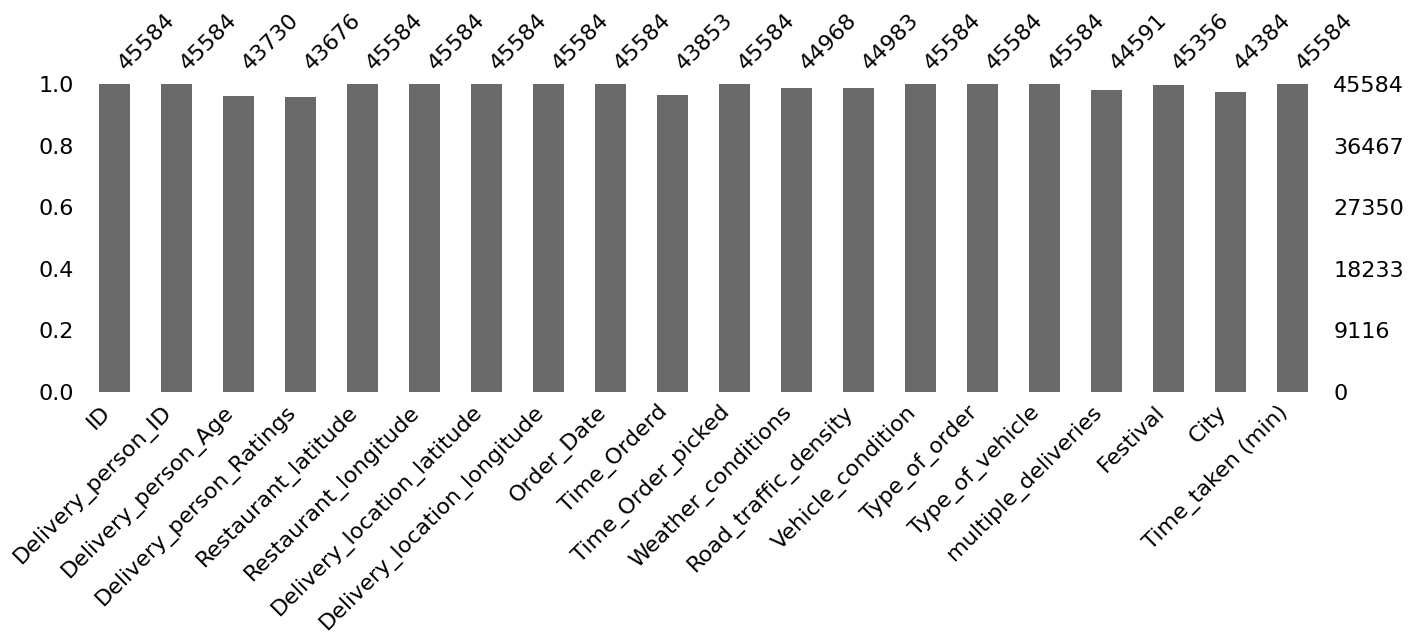

In [11]:
import missingno as msno

msno.bar(df, figsize=(16,4))
plt.show()


In [12]:
if df.duplicated().sum() > 0:
    df[df.duplicated()]
else : 
    print('Tidak ada data duplikat')

Tidak ada data duplikat


#### **1.4 Handling Missing Value**

In [13]:
# karena missing data di bawah 5 persen maka data yang null akan di hapus 


print(f'data missing : \n{round( df.isnull().sum()[df.isnull().sum() > 0] / len(df)*100),2}')

df = df.dropna()

print(df.isnull().sum())

data missing : 
(Delivery_person_Age        4.0
Delivery_person_Ratings    4.0
Time_Orderd                4.0
Weather_conditions         1.0
Road_traffic_density       1.0
multiple_deliveries        2.0
Festival                   1.0
City                       3.0
dtype: float64, 2)
ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
dtype: int64


### **EDA**

1. This stage will perform EDA on both numerical and categorical columns.
2. Conduct analysis on columns that should be in date format but are currently in object format.
3. Convert longitude and latitude columns into distance using **geopy**.


#### **2.1 Distribution of Numerical Columns**


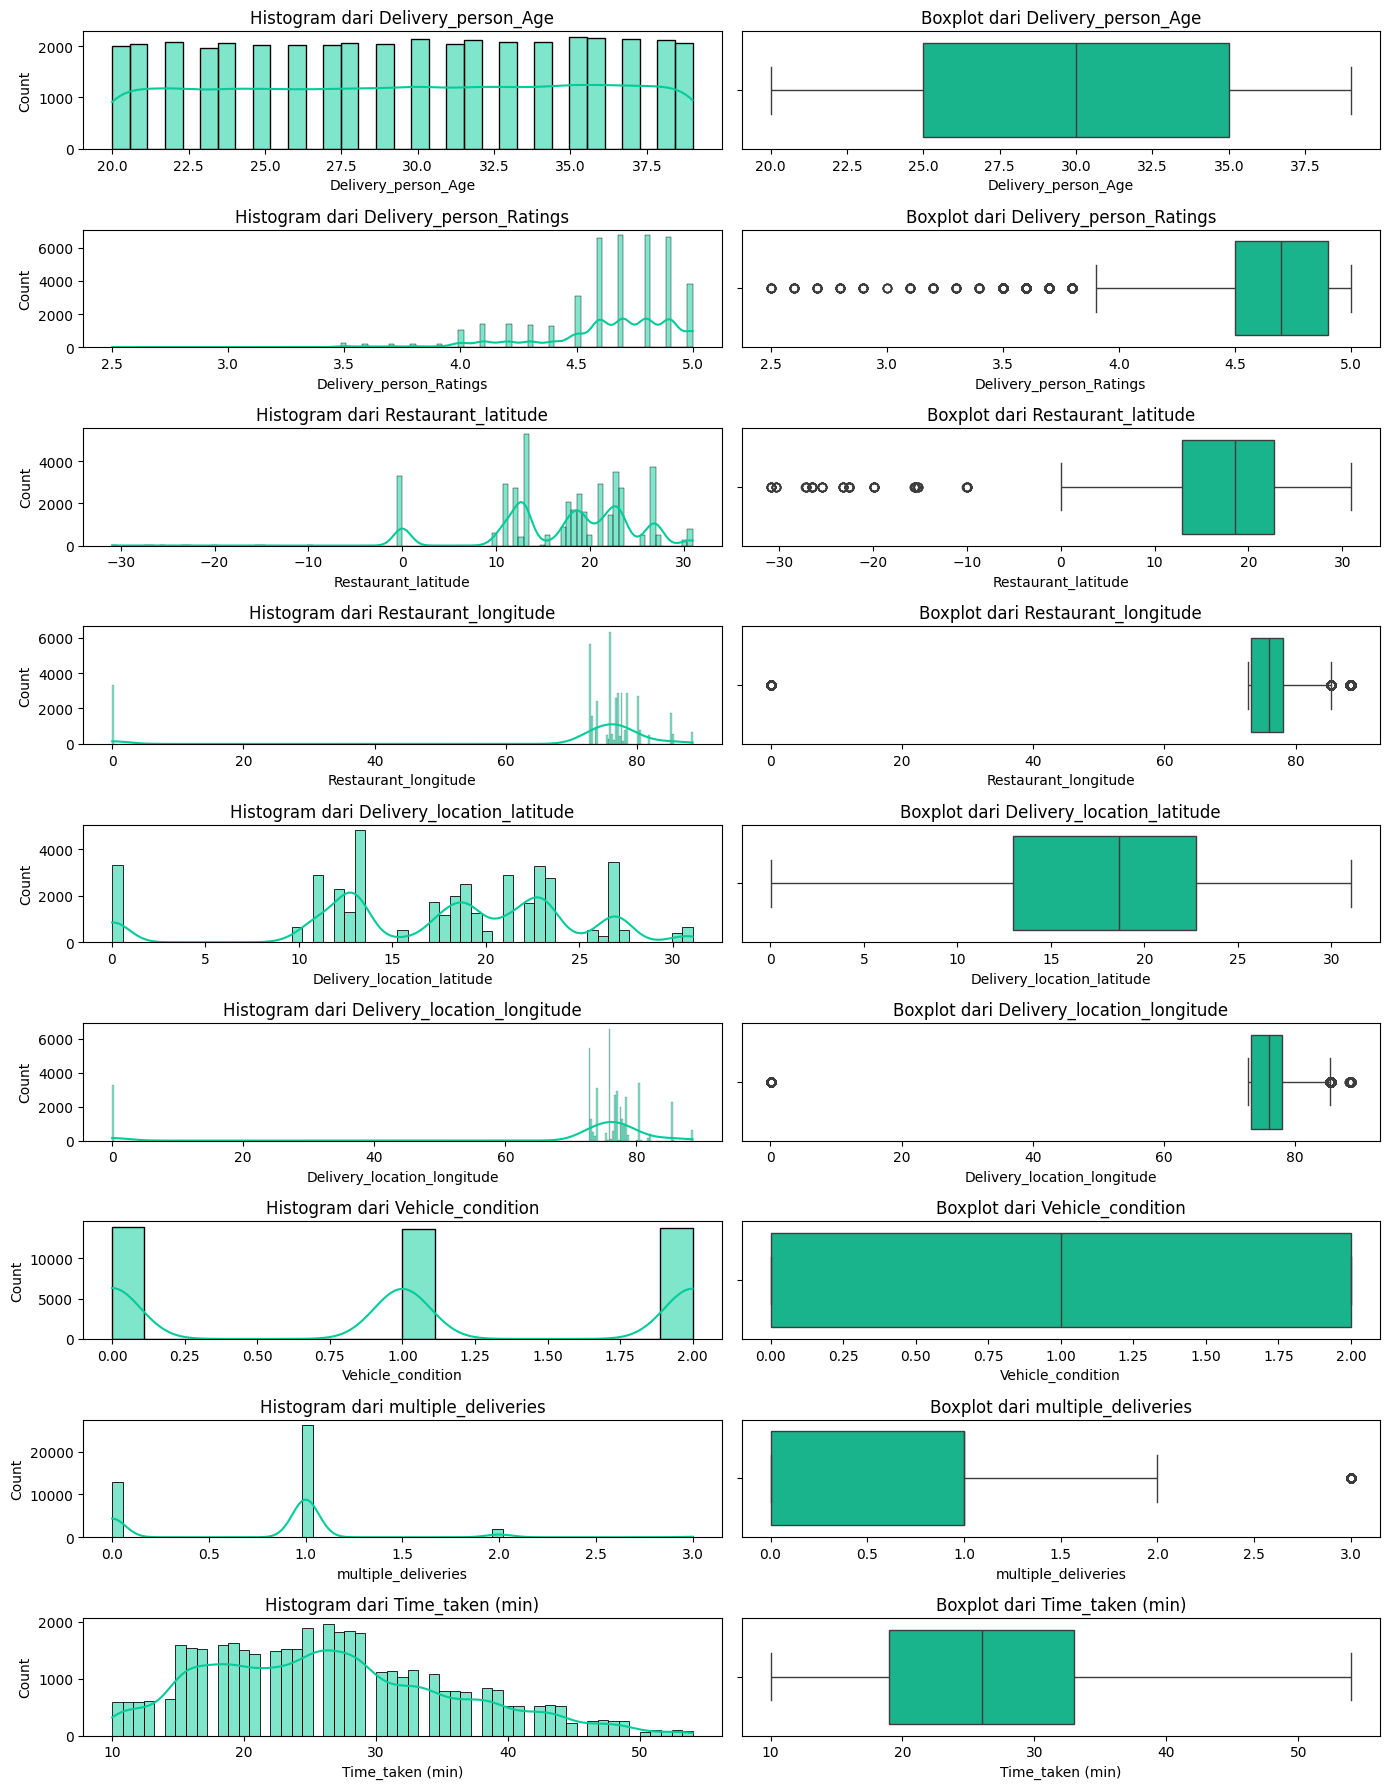

In [14]:
num = [i for i in df.columns if df[i].dtypes != 'object']

# Membuat grafik histogram dan boxplot
fig, axes = plt.subplots(nrows=len(num), ncols=2, figsize=(14, 2*len(num)))

for i, kolom in enumerate(num):
    # Histogram
    sns.histplot(df[kolom], ax=axes[i, 0], kde=True,color='#00cc99')
    axes[i, 0].set_title(f'Histogram dari {kolom}')

    # Boxplot
    sns.boxplot(data=df, x=kolom, ax=axes[i, 1], orient='h',color='#00cc99')
    axes[i, 1].set_title(f'Boxplot dari {kolom}')

plt.tight_layout()
plt.show()

| **Variable**                    | **Distribution Pattern (Histogram)**           | **Findings from Boxplot (Outliers)** | **Main Interpretation / Highlight**                                             |
| ------------------------------- | ---------------------------------------------- | ------------------------------------ | ------------------------------------------------------------------------------- |
| **Delivery_person_Age**         | Evenly distributed between ages 20–40          | No significant outliers              | The couriers’ ages are evenly spread, with no dominant age group.               |
| **Delivery_person_Ratings**     | Majority between 4.0–5.0                       | Some outliers below 3                | Most couriers perform well, receiving high ratings.                             |
| **Restaurant_latitude**         | Wide distribution across locations             | Some extreme outliers                | Restaurant locations are highly varied; geographic normalization may be needed. |
| **Restaurant_longitude**        | Wide spread with multiple peaks                | Significant outliers present         | Indicates wide operational coverage (possibly multiple service areas).          |
| **Delivery_location_latitude**  | Distributed across a wide range of values      | Some outliers                        | Delivery destinations are widely spread, similar to restaurant locations.       |
| **Delivery_location_longitude** | Broad distribution with peaks in certain areas | Some outliers                        | High location variability, potentially affecting delivery time.                 |
| **Vehicle_condition**           | Mainly two categories (0 and 1)                | No outliers                          | Vehicle condition is generally uniform and good.                                |
| **multiple_deliveries**         | Mostly single deliveries, few above 1          | Outliers at value 3                  | Most couriers deliver one order, while a few handle multiple deliveries.        |
| **Time_taken (min)**            | Right-skewed (most under 30 minutes)           | Outliers at high values              | Delivery time varies; some cases take much longer due to specific conditions.   |


#### **2.2 Correlation of Numerical Columns**

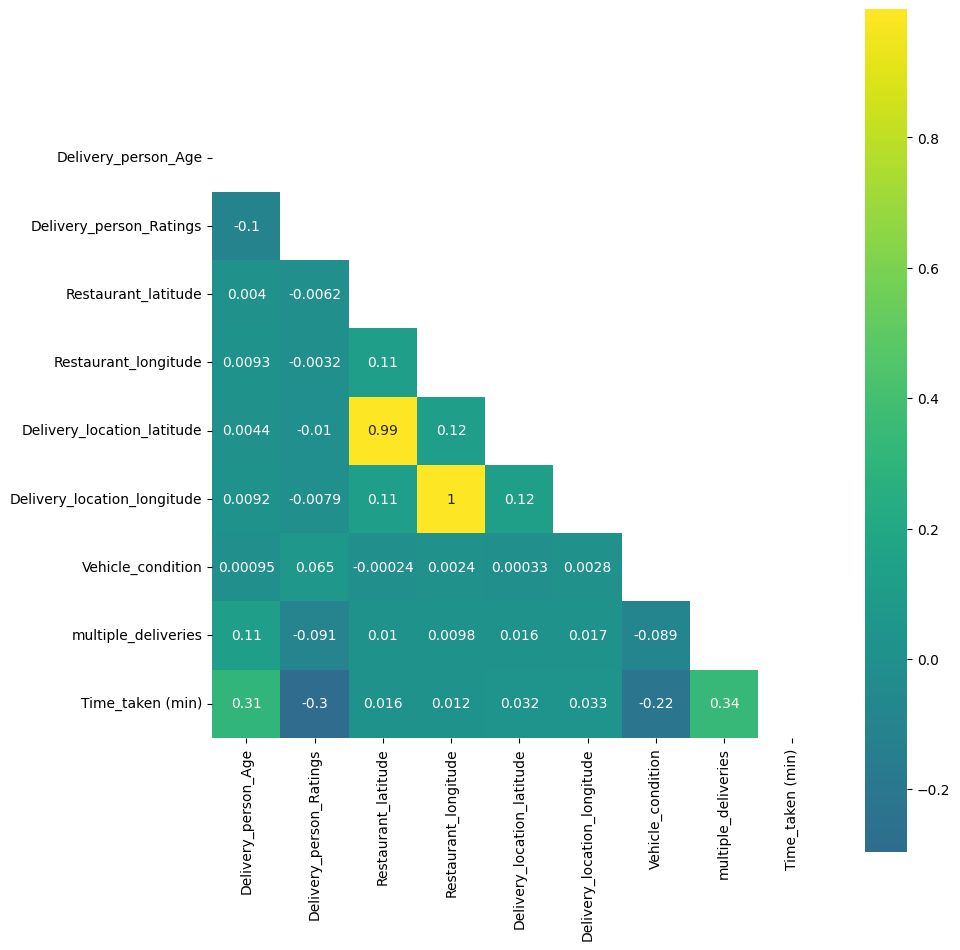

In [15]:
corr = df.corr(numeric_only=True,method='spearman')
plt.figure(figsize=(10,10))

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True,cmap='viridis',square=True,center=0,mask=mask)
plt.tight_layout()
plt.show()

**Correlation Interpretation of `Time_taken (min)`**

| **Variable**                                                                 | **Correlation with Time_taken (min)** | **Relationship Direction** | **Main Interpretation**                                                      |
| ---------------------------------------------------------------------------- | ------------------------------------- | -------------------------- | ---------------------------------------------------------------------------- |
| **Delivery_person_Age**                                                      | **0.31**                              | Moderate positive          | Older couriers tend to have slightly longer delivery times.                  |
| **Delivery_person_Ratings**                                                  | **-0.30**                             | Moderate negative          | Couriers with higher ratings tend to complete deliveries faster.             |
| **Vehicle_condition**                                                        | **-0.22**                             | Weak negative              | Better vehicle condition helps reduce delivery time.                         |
| **multiple_deliveries**                                                      | **0.34**                              | Moderate positive          | The more orders delivered simultaneously, the longer the delivery time.      |
| **Restaurant_latitude / longitude & Delivery_location_latitude / longitude** | **≈ 0.01–0.03**                       | Almost no correlation      | Geographic coordinates have little to no direct effect on delivery duration. |

**Conclusion:**
The factors that most influence delivery time (`Time_taken`) are **the number of simultaneous deliveries (multiple_deliveries)**, **courier’s age**, and **driver rating**. Meanwhile, **vehicle condition** has a smaller impact, and **geographic location** shows no significant influence.


#### **2.3 Distribution of Categorical Columns**

In [16]:

categorical = df[['Weather_conditions','Road_traffic_density','Type_of_order','Type_of_vehicle','Festival','City']]

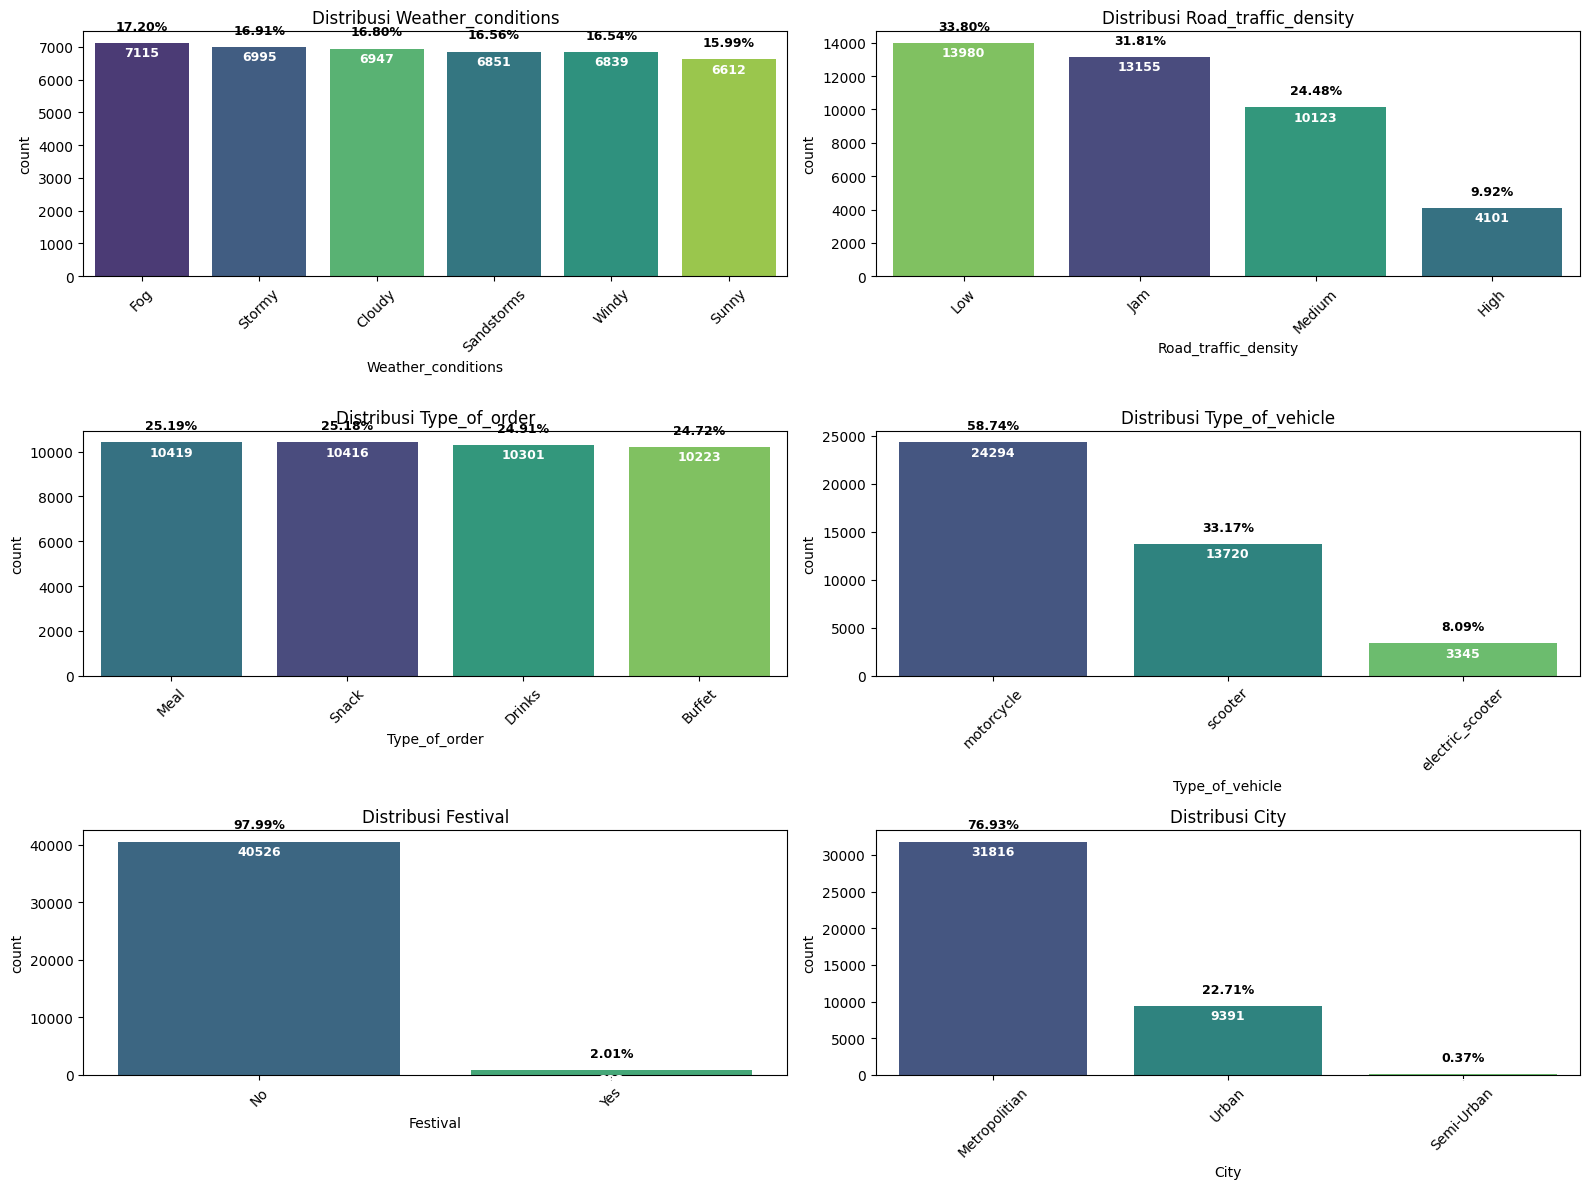

In [17]:

# Fungsi untuk anotasi jumlah
def annotate_bar_plot(ax):
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.0f}',  
                    (bar.get_x() + bar.get_width() / 2., bar.get_height()),  
                    ha='center', va='center',  
                    xytext=(0, -7),  
                    textcoords='offset points',  
                    fontsize=9, color='white', fontweight='semibold')

# Fungsi untuk anotasi persentase
def annotate_bar_plot_percent(ax, total):
    for bar in ax.patches:
        height = bar.get_height()
        ax.annotate(f'{height/total:.2%}',  
                    (bar.get_x() + bar.get_width() / 2., height),  
                    ha='center', va='center',  
                    xytext=(0, 12),  
                    textcoords='offset points',  
                    fontsize=9, color='black', fontweight='semibold')

# Fungsi utama untuk plot semua kolom kategorikal
def plot_categorical_distribution(categorical, ncols=2, palette="viridis"):
    obj_cols = categorical.select_dtypes(include="object").columns.tolist()
    total = len(categorical)
    
    nrows = (len(obj_cols) + ncols - 1) // ncols  # hitung jumlah baris
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8*ncols, 4*nrows))
    axes = axes.flatten()

    for i, col in enumerate(obj_cols):
        ax = axes[i]
        sns.countplot(data=categorical, x=col, ax=ax, palette=palette, order=categorical[col].value_counts().index,hue=categorical[col])
        ax.set_title(f"Distribusi {col}")
        ax.tick_params(axis="x", rotation=45)

        # Tambahkan anotasi
        annotate_bar_plot(ax)
        annotate_bar_plot_percent(ax, total)

    # Kosongkan axis yang tidak terpakai
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.style.use('ggplot')
    plt.show()

plot_categorical_distribution(categorical)

| **Variable**             | **Distribution & Interpretation**                                                                                                                                                                                                                                                                                       |
| ------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Weather_conditions**   | Weather conditions are relatively balanced among *Fog (17.20%)*, *Stormy (16.91%)*, *Cloudy (16.80%)*, *Sandstorms (16.54%)*, *Windy (16.53%)*, and *Sunny (15.99%)*. This indicates that weather does not significantly affect the number of orders — delivery activity is fairly consistent across all weather types. |
| **Road_traffic_density** | Most deliveries occur under *Low (33.80%)* and *Jam (31.81%)* traffic conditions, while *Medium (24.48%)* and *High (9.92%)* are less frequent. This suggests that the majority of deliveries are made when traffic is relatively smooth.                                                                               |
| **Type_of_order**        | The distribution of orders is quite even among *Meal (25.19%)*, *Snack (25.13%)*, *Drinks (24.81%)*, and *Buffet (24.72%)*. There is no dominant category, indicating a balanced variety of order types among customers.                                                                                                |
| **Type_of_vehicle**      | Most deliveries are made using *motorcycles (58.74%)*, followed by *scooters (33.17%)*, and *electric scooters (8.09%)*. This shows that conventional motorized vehicles remain the primary choice due to their efficiency and delivery speed.                                                                          |
| **Festival**             | Only *2.01%* of deliveries occur during festivals, while *97.99%* take place on regular days. This suggests that delivery activity is not significantly affected by special events or festivals.                                                                                                                        |
| **City**                 | Most deliveries are carried out in *Metropolitan areas (76.93%)*, followed by *Urban (22.71%)*, and *Semi-Urban (0.37%)*. This indicates that the service is most active in large urban areas with high demand.                                                                                                         |


#### **2.4 EDA of the Time_ordered and Time_Order_picked Columns**

In [18]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'],dayfirst=True)

In [19]:
# nilai unique 

df['Time_Orderd'].unique()

array(['21:55', '14:55', '17:30', '09:20', '19:50', '20:25', '20:30',
       '21:15', '20:20', '22:30', '08:15', '19:30', '12:25', '18:35',
       '20:35', '23:20', '21:20', '23:35', '22:35', '23:25', '13:35',
       '21:35', '18:55', '14:15', '0.458333333', '09:45', '08:40',
       '0.958333333', '17:25', '19:45', '19:10', '10:55', '21:40',
       '0.791666667', '16:45', '11:30', '15:10', '22:45', '22:10',
       '20:45', '22:50', '17:55', '20:15', '22:25', '22:40', '23:50',
       '15:25', '10:20', '20:55', '10:40', '15:55', '20:10', '12:10',
       '15:30', '10:35', '21:10', '20:50', '12:35', '0.875', '23:40',
       '18:15', '18:20', '11:45', '12:45', '23:30', '10:50', '21:25',
       '10:10', '17:50', '22:20', '12:40', '23:55', '10:25', '08:45',
       '23:45', '19:55', '22:15', '23:10', '18:25', '18:45', '16:50', '1',
       '14:20', '10:15', '08:50', '0.375', '17:45', '16:35', '08:30',
       '21:45', '14:50', '18:10', '12:20', '12:50', '09:10', '12:30',
       '17:10', '19:15',

In [20]:
df['Time_Order_picked'].unique()

array(['22:10', '15:05', '17:40', '09:30', '20:05', '20:35', '15:10',
       '20:40', '21:30', '20:25', '22:45', '08:30', '19:45', '12:30',
       '18:50', '23:30', '21:35', '23:45', '22:50', '22:40', '23:35',
       '13:40', '21:45', '19:10', '14:25', '11:10', '09:55', '08:55',
       '23:10', '17:30', '19:50', '19:25', '0.458333333', '19:15',
       '16:55', '11:40', '15:15', '22:55', '22:25', '20:55', '23:05',
       '0.75', '0.958333333', '20:50', '20:20', '22:35', '0.916666667',
       '23:55', '15:40', '10:30', '0.875', '10:50', '16:05', '20:15',
       '12:15', '15:45', '22:15', '10:45', '24:05:00', '21:25', '12:45',
       '21:15', '18:20', '18:25', '11:50', '12:50', '10:55', '21:40',
       '10:20', '17:55', '23:50', '12:55', '24:10:00', '10:40', '0.375',
       '20:45', '0.833333333', '23:15', '18:35', '22:20', '21:05',
       '0.708333333', '24:15:00', '21:20', '14:35', '10:25', '09:05',
       '16:50', '08:40', '23:40', '21:50', '0.625', '10:35', '09:25',
       '17:20', '1

The format of both columns is inconsistent, with time data appearing in different formats; therefore, two approaches will be used to standardize the format.


In [21]:
def parse_time(x):
    try:
        x = str(x).strip()
        if ":" in x:  # format jam menit
            return pd.to_datetime(x, format="%H:%M", errors="coerce").time()
        else:  # format desimal (Excel style)
            val = float(x)
            minutes = int(round(val * 24 * 60))  # konversi fraction of day ke menit
            hours, mins = divmod(minutes, 60)
            hours = hours % 24  # biar ga lebih dari 24
            return pd.to_datetime(f"{hours:02d}:{mins:02d}", format="%H:%M").time()
    except:
        return pd.NaT

df['Time_Orderd'] = df['Time_Orderd'].apply(parse_time)
df['Time_Order_picked'] = df['Time_Order_picked'].apply(parse_time)

In [22]:
df['Time_Orderd'].unique()[:10]

array([datetime.time(21, 55), datetime.time(14, 55),
       datetime.time(17, 30), datetime.time(9, 20), datetime.time(19, 50),
       datetime.time(20, 25), datetime.time(20, 30),
       datetime.time(21, 15), datetime.time(20, 20),
       datetime.time(22, 30)], dtype=object)

In [23]:
df['Time_Order_picked'].unique()[:10]

array([datetime.time(22, 10), datetime.time(15, 5), datetime.time(17, 40),
       datetime.time(9, 30), datetime.time(20, 5), datetime.time(20, 35),
       datetime.time(15, 10), datetime.time(20, 40),
       datetime.time(21, 30), datetime.time(20, 25)], dtype=object)

Both time columns have been successfully converted and standardized to facilitate analysis.


#### **2.5 Distance Analysis Using Longitude and Latitude Data**


In [24]:

df.iloc[:, [4,5,6,7]]

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
0,30.327968,78.046106,30.397968,78.116106
1,10.003064,76.307589,10.043064,76.347589
2,18.562450,73.916619,18.652450,74.006619
3,30.899584,75.809346,30.919584,75.829346
4,26.463504,80.372929,26.593504,80.502929
...,...,...,...,...
45579,26.902328,75.794257,26.912328,75.804257
45580,0.000000,0.000000,0.070000,0.070000
45581,13.022394,80.242439,13.052394,80.272439
45582,11.001753,76.986241,11.041753,77.026241


Based on the latitude and longitude data, we will use the **geopy** library to calculate the travel distance.


In [25]:
from geopy.distance import geodesic

df['Restaurant_latitude'] = df['Restaurant_latitude'].abs()

df['Delivery_location_latitude'] = df['Delivery_location_latitude'].abs()

# fungsi untuk menghitung jarak
def calc_distance(row):
    resto = (row['Restaurant_latitude'], row['Restaurant_longitude'])
    delivery = (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
    return geodesic(resto, delivery).km   # hasil dalam kilometer

# apply ke dataframe
df['Distance_km'] = df.apply(calc_distance, axis=1)

In [26]:
pd.set_option('display.max_columns',None)
df.head(2)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Distance_km
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55:00,22:10:00,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.271464
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55:00,15:05:00,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.229376


In [27]:
df['Distance_km'].unique()[:50]

array([10.27146402,  6.22937608, 13.76430593,  2.92779473, 19.37348409,
       13.74093223,  6.20558995, 16.82119165,  4.53389559, 12.23513612,
       19.59099422,  1.55495018, 20.14090526,  6.10673694, 17.04198396,
        4.46506838, 13.66073758, 13.94563444, 16.82479191,  4.66463078,
        7.58976942,  7.70594197,  6.16414376, 17.25937672, 19.88068891,
       10.70618436,  6.11736906,  1.51798713,  3.06801653,  3.09901009,
       10.84601359, 10.84409404, 13.66119938, 16.79799879,  3.02278047,
        9.15984737,  9.2967121 ,  6.19680534,  1.51797481,  6.02867401,
       17.04498826,  4.70710405, 12.43888855,  9.10722002, 13.99459241,
       13.37733286, 12.55227576,  9.41420747, 11.90275384,  4.65425682])

In [28]:
df[df['Distance_km'] > 15].iloc[:,[4,5,6,7,-1]]

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Distance_km
4,26.463504,80.372929,26.593504,80.502929,19.373484
7,18.592718,73.773572,18.702718,73.883572,16.821192
11,23.357804,85.325146,23.487804,85.455146,19.590994
13,12.986047,80.218114,13.116047,80.348114,20.140905
15,13.005801,80.250744,13.115801,80.360744,17.041984
...,...,...,...,...,...
45553,30.340722,78.060221,30.470722,78.190221,19.072081
45559,12.352058,76.606650,12.462058,76.716650,17.062996
45567,0.000000,0.000000,0.130000,0.130000,20.397443
45574,12.310972,76.659264,12.440972,76.789264,20.166508


There are delivery distances of up to 20 km; let’s take a closer look at the **multiple_deliveries** variable to see if there is any relationship.


In [29]:
df[df['Distance_km'] > 15]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Distance_km
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50:00,20:05:00,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.373484
7,0x689b,PUNERES20DEL01,33.0,4.2,18.592718,73.773572,18.702718,73.883572,2022-03-16,20:30:00,20:40:00,Sandstorms,Jam,2,Snack,motorcycle,1.0,No,Metropolitian,40,16.821192
11,0x5795,RANCHIRES06DEL02,31.0,4.7,23.357804,85.325146,23.487804,85.455146,2022-03-10,22:30:00,22:45:00,Sandstorms,Low,2,Meal,electric_scooter,0.0,No,Metropolitian,26,19.590994
13,0xb816,CHENRES19DEL02,33.0,4.3,12.986047,80.218114,13.116047,80.348114,2022-03-27,19:30:00,19:45:00,Windy,Jam,2,Meal,scooter,1.0,No,Metropolitian,39,20.140905
15,0xa1b2,CHENRES01DEL01,29.0,4.5,13.005801,80.250744,13.115801,80.360744,2022-03-27,18:35:00,18:50:00,Sunny,Medium,2,Meal,electric_scooter,1.0,No,Metropolitian,15,17.041984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45553,0xd5c3,DEHRES04DEL02,34.0,4.5,30.340722,78.060221,30.470722,78.190221,2022-02-12,19:35:00,19:45:00,Stormy,Jam,2,Buffet,electric_scooter,1.0,No,Urban,27,19.072081
45559,0xaec7,MYSRES15DEL01,25.0,4.7,12.352058,76.606650,12.462058,76.716650,2022-03-16,19:55:00,20:05:00,Stormy,Jam,0,Snack,motorcycle,0.0,No,Metropolitian,25,17.062996
45567,0x2bed,RANCHIRES02DEL02,34.0,4.2,0.000000,0.000000,0.130000,0.130000,2022-04-04,17:25:00,17:30:00,Stormy,Medium,0,Drinks,motorcycle,3.0,No,Urban,48,20.397443
45574,0x5193,MYSRES13DEL02,36.0,4.8,12.310972,76.659264,12.440972,76.789264,2022-03-18,21:10:00,21:20:00,Sunny,Jam,2,Drinks,electric_scooter,1.0,No,Urban,29,20.166508


In [30]:
df.groupby(['multiple_deliveries'])[['Distance_km']].describe()

Distance_km                                            \
                          count       mean       std       min        25%   
multiple_deliveries                                                         
0.0                     12973.0   9.107609  5.550861  1.463927   4.554155   
1.0                     26168.0   9.809384  5.589254  1.463837   4.664643   
2.0                      1881.0  12.976063  4.808310  1.463953  10.571405   
3.0                       337.0  12.961418  4.682939  1.488175  10.577818   

                                                      
                           50%        75%        max  
multiple_deliveries                                   
0.0                   7.845173  12.552276  20.942906  
1.0                   9.294981  13.661199  20.942906  
2.0                  12.410726  16.822581  20.942420  
3.0                  13.173609  16.797999  20.828114

| **Order Category**  | **Average (km)** | **Median (km)** | **Maximum (km)** | **Interpretation**                                                                               |
| ------------------- | ---------------- | --------------- | ---------------- | ------------------------------------------------------------------------------------------------ |
| **Single (0.0)**    | 9.1              | 7.8             | 20.9             | Most single deliveries are relatively close. The upper safe limit for single orders is 20.9 km.  |
| **Double (1.0)**    | 9.8              | 9.3             | 20.9             | Slightly farther than single orders, which is reasonable since drivers must reach two addresses. |
| **Triple (2.0)**    | 13.0             | 12.4            | 20.9             | The distance increases significantly. The more orders, the longer the average distance.          |
| **Quadruple (3.0)** | 13.0             | 13.0            | 20.9             | Similar to triple orders; likely fewer samples (337 rows), but the trend remains consistent.     |


In [31]:
df.groupby(['multiple_deliveries']).agg(
    mean_distance = ('Distance_km','mean'),
    mean_time = ('Time_taken (min)', 'mean'),
    median_distance = ('Distance_km','median'),
    median_time = ('Time_taken (min)', 'median')
)

,mean_distance,mean_time,median_distance,median_time
multiple_deliveries,,,,
0.0,9.107609,23.106529,7.845173,22.0
1.0,9.809384,26.986931,9.294981,26.0
2.0,12.976063,40.467836,12.410726,40.0
3.0,12.961418,47.827893,13.173609,48.0


Let's compare it with the **distance traveled per minute in urban areas** to determine a reasonable threshold.


In [32]:
df['distance_per_mnt'] = df['Distance_km'] / df['Time_taken (min)']

In [33]:
df.groupby(['multiple_deliveries'])[['distance_per_mnt']].agg(['mean','median','min','max'])

distance_per_mnt                              
                                mean    median       min       max
multiple_deliveries                                               
0.0                         0.426360  0.360916  0.032544  2.082946
1.0                         0.383523  0.336222  0.030368  2.016551
2.0                         0.322702  0.313724  0.031456  0.633252
3.0                         0.272869  0.265948  0.028231  0.484363

**Interpretation of `distance_per_mnt`**

| **Multiple Deliveries** | **Mean (km/min)** | **Median (km/min)** | **Min** | **Max** | **Brief Interpretation**                                      |
| ----------------------- | ----------------- | ------------------- | ------- | ------- | ------------------------------------------------------------- |
| **0.0 (Single)**        | 0.426             | 0.361               | 0.03    | 2.08    | Highest efficiency → routes are more direct and faster.       |
| **1.0 (Double)**        | 0.384             | 0.336               | 0.03    | 2.02    | Slightly slower, reasonable since there are two destinations. |
| **2.0 (Triple)**        | 0.323             | 0.314               | 0.03    | 0.63    | Significant decrease → routes become more complex.            |
| **3.0 (Quadruple)**     | 0.273             | 0.266               | 0.03    | 0.48    | Lowest efficiency, most complex routes.                       |

**Conclusion:**

* There is a downward trend from single → quadruple deliveries — the more orders handled, **the smaller the average distance covered per minute**.
* Single deliveries are the most efficient, while multiple deliveries reduce travel time efficiency.

Further analysis will be presented in the next subsection regarding **outliers**.


#### **Analysis of the Target Variable**


Since we have obtained a new variable representing distance based on longitude and latitude, several variables will be removed.


In [34]:
df = df.drop(columns=['ID','Delivery_person_ID','Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude','Order_Date'])

df.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Distance_km,distance_per_mnt
0,36.0,4.2,21:55:00,22:10:00,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.271464,0.223293
1,21.0,4.7,14:55:00,15:05:00,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.229376,0.270842


#### **3.1 Numerical Analysis vs Target**


In [35]:
num_col = df.select_dtypes(include='number').columns.to_list()
num_col

['Delivery_person_Age',
 'Delivery_person_Ratings',
 'Vehicle_condition',
 'multiple_deliveries',
 'Time_taken (min)',
 'Distance_km',
 'distance_per_mnt']

In [36]:
num_col.remove('Time_taken (min)')

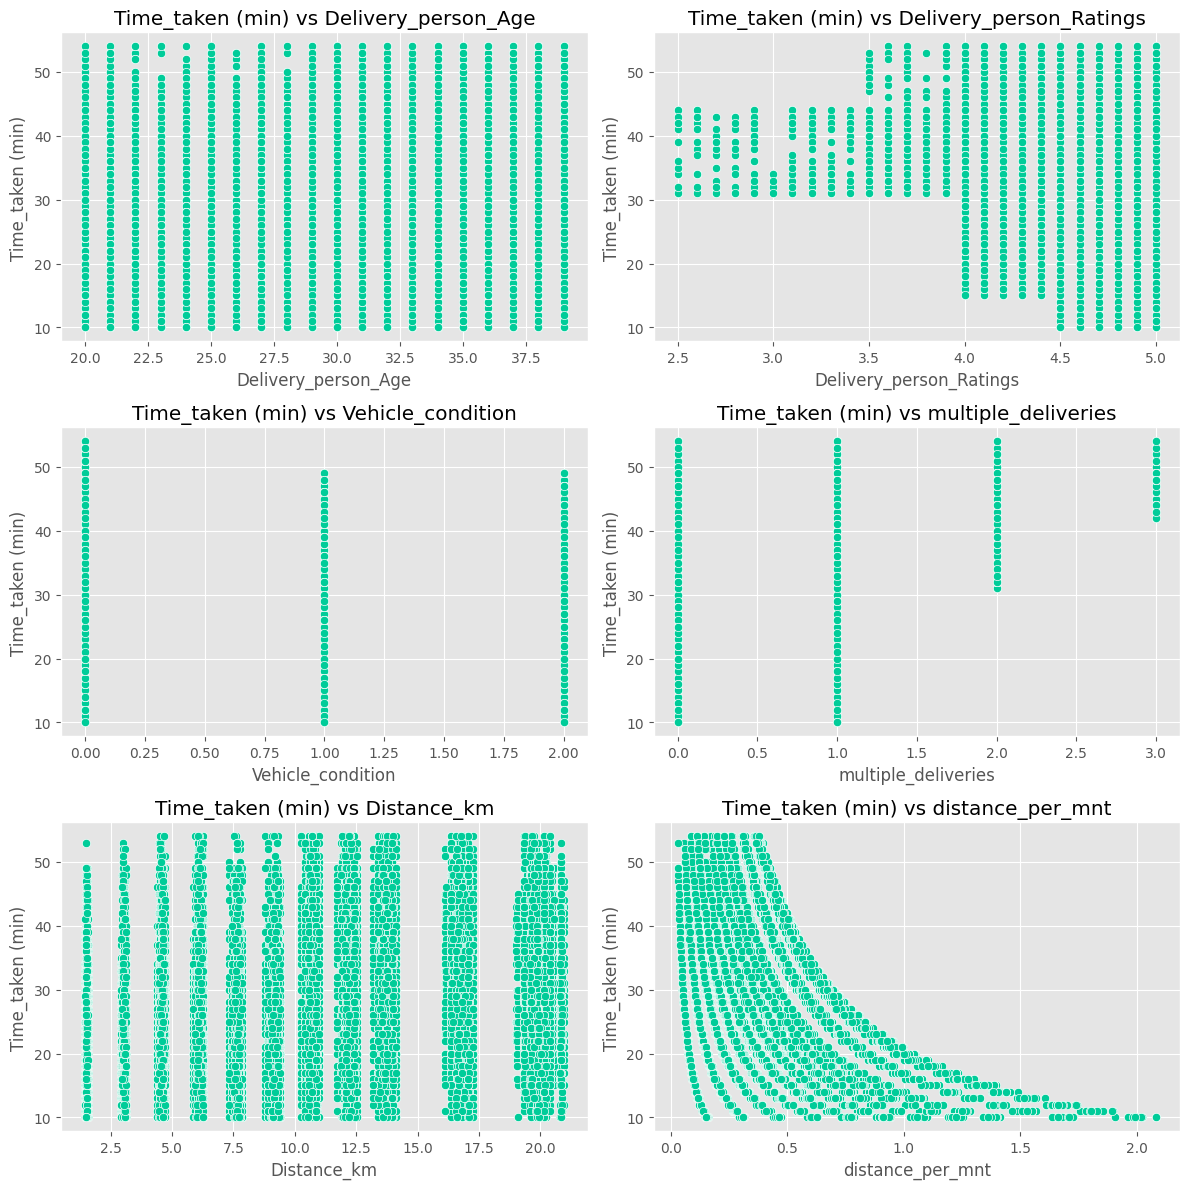

In [37]:
import math
targets = ['Time_taken (min)']


# Loop untuk setiap target
for target in targets:
    n = len(num_col)
    rows = math.ceil(n / 2)  # 2 kolom per baris
    cols = 2

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
    axes = axes.flatten()

    for i, feature in enumerate(num_col):
        sns.scatterplot(data=df, x=feature, y=target, ax=axes[i], color='#00cc99')
        axes[i].set_title(f'{target} vs {feature}')

    # Hapus subplot kosong jika ada
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


| **Variable**                                  | **Interpretation**                                                                                                                                                                                                                                                                                                                                                           |
| --------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Delivery_person_Age**                       | The graph shows no clear relationship between the courier's age and delivery time. Delivery times tend to be randomly distributed across all age ranges (20–39 years). This means that **age is not a significant factor in determining delivery speed**.                                                                                                                    |
| **Delivery_person_Ratings**                   | It can be seen that couriers with **high ratings (≥4.0)** tend to have faster and more consistent delivery times, typically around 10–30 minutes. On the other hand, couriers with **low ratings (<3.5)** tend to have more variable and longer delivery times. This indicates a **positive correlation between courier service quality (ratings) and delivery efficiency**. |
| **Vehicle_condition**                         | There is no noticeable difference among vehicle conditions (good, fair, poor). Most delivery times remain in the 20–35 minute range for all conditions. Thus, **vehicle condition does not have a major effect on delivery time**, possibly because vehicle maintenance standards are relatively uniform across the fleet.                                                   |
| **multiple_deliveries**                       | It is evident that as the number of deliveries made in one trip increases (1 → 3), **delivery time increases significantly**. This means that **multiple deliveries add route complexity and travel time**, thereby increasing total delivery duration.                                                                                                                      |
| **Distance_km**                               | There is a **strong positive relationship** between distance and delivery time — the farther the distance, the longer it takes. Delivery time increases almost linearly with distance up to around 20 km, confirming that **distance is one of the main factors affecting delivery duration**.                                                                               |
| **distance_per_mnt (distance-to-time ratio)** | The relationship between *distance_per_mnt* and *Time_taken* appears as a **downward exponential curve**. The higher the *distance_per_mnt* value (indicating higher speed), the shorter the delivery time. This reinforces the logical relationship that **the more efficient the travel speed, the faster the delivery is completed**.                                     |

**General Conclusion**

1. **The most influential factors affecting delivery time** are:

   * **Distance_km (delivery distance)**
   * **multiple_deliveries (number of deliveries per trip)**
   * **Delivery_person_Ratings (courier rating)**
   * **distance_per_mnt (effective speed)**

2. **Factors with minimal influence**: age and vehicle condition.

3. Efficiency improvement strategies can focus on **optimizing route management, reducing multiple deliveries, and providing training to improve courier performance**.


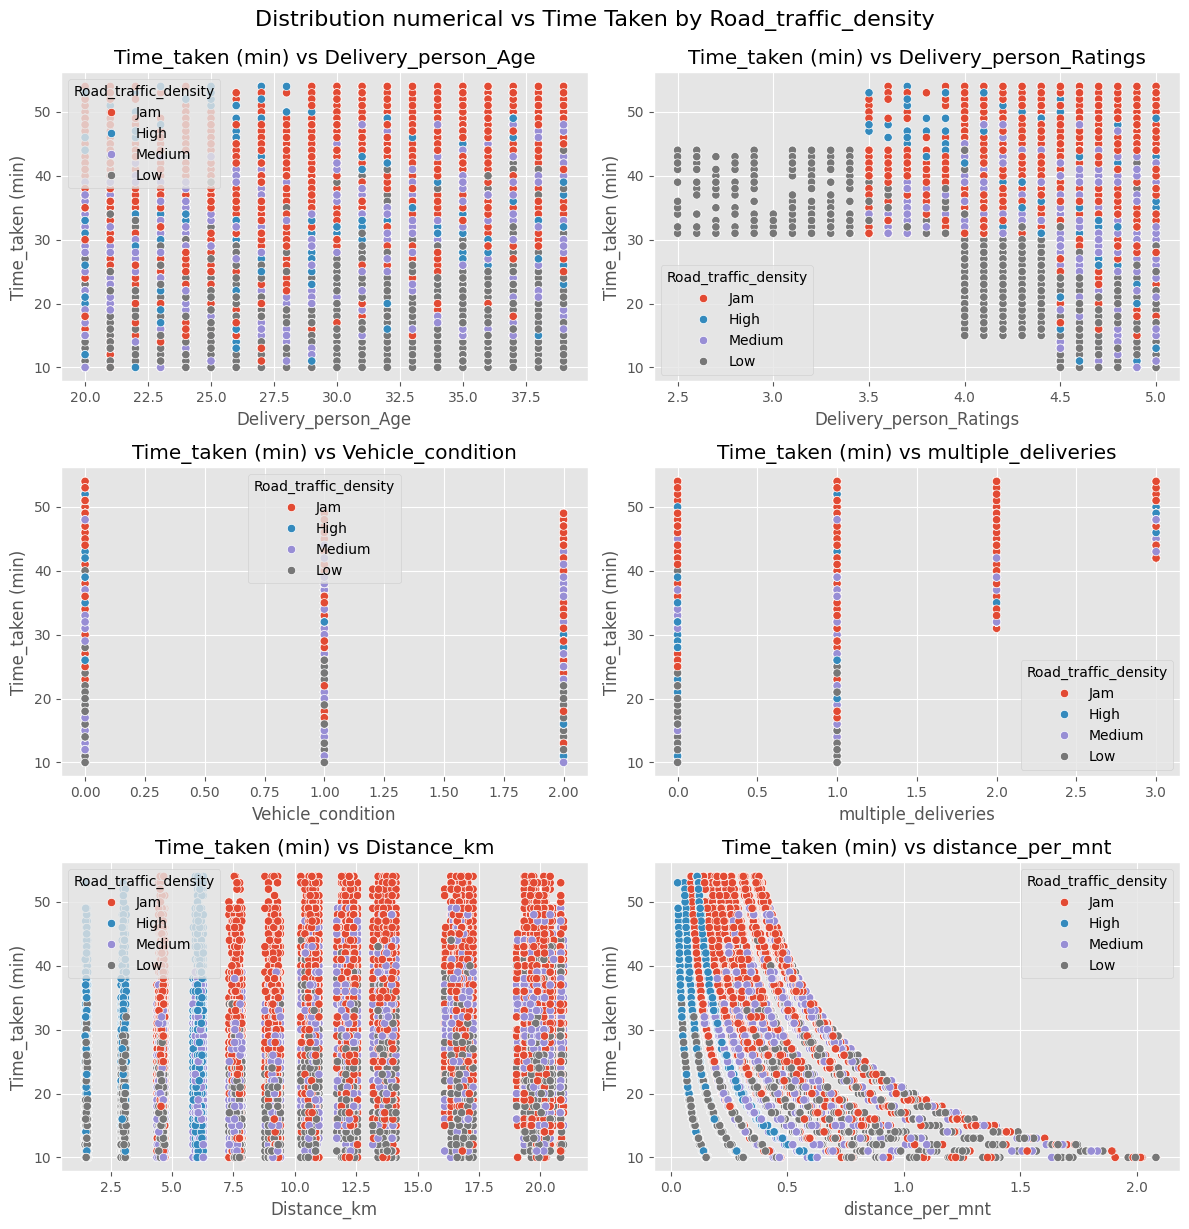

In [38]:

def num_plot_target(hue,title):
    targets = ['Time_taken (min)']


    # Loop untuk setiap target
    for target in targets:
        n = len(num_col)
        rows = math.ceil(n / 2)  # 2 kolom per baris
        cols = 2

        fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
        axes = axes.flatten()

        for i, feature in enumerate(num_col):
            sns.scatterplot(data=df, x=feature, y=target, ax=axes[i], color='#00cc99', hue=hue)
            axes[i].set_title(f'{target} vs {feature}')

        # Hapus subplot kosong jika ada
        for j in range(i+1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.suptitle(title, fontsize=16, y=1.02)
        plt.show()

num_plot_target('Road_traffic_density','Distribution numerical vs Time Taken by Road_traffic_density')

#### **3.2 Analysis of Categorical Columns vs Target**


In [39]:
df.select_dtypes(include='object').columns.to_list()

['Time_Orderd',
 'Time_Order_picked',
 'Weather_conditions',
 'Road_traffic_density',
 'Type_of_order',
 'Type_of_vehicle',
 'Festival',
 'City']

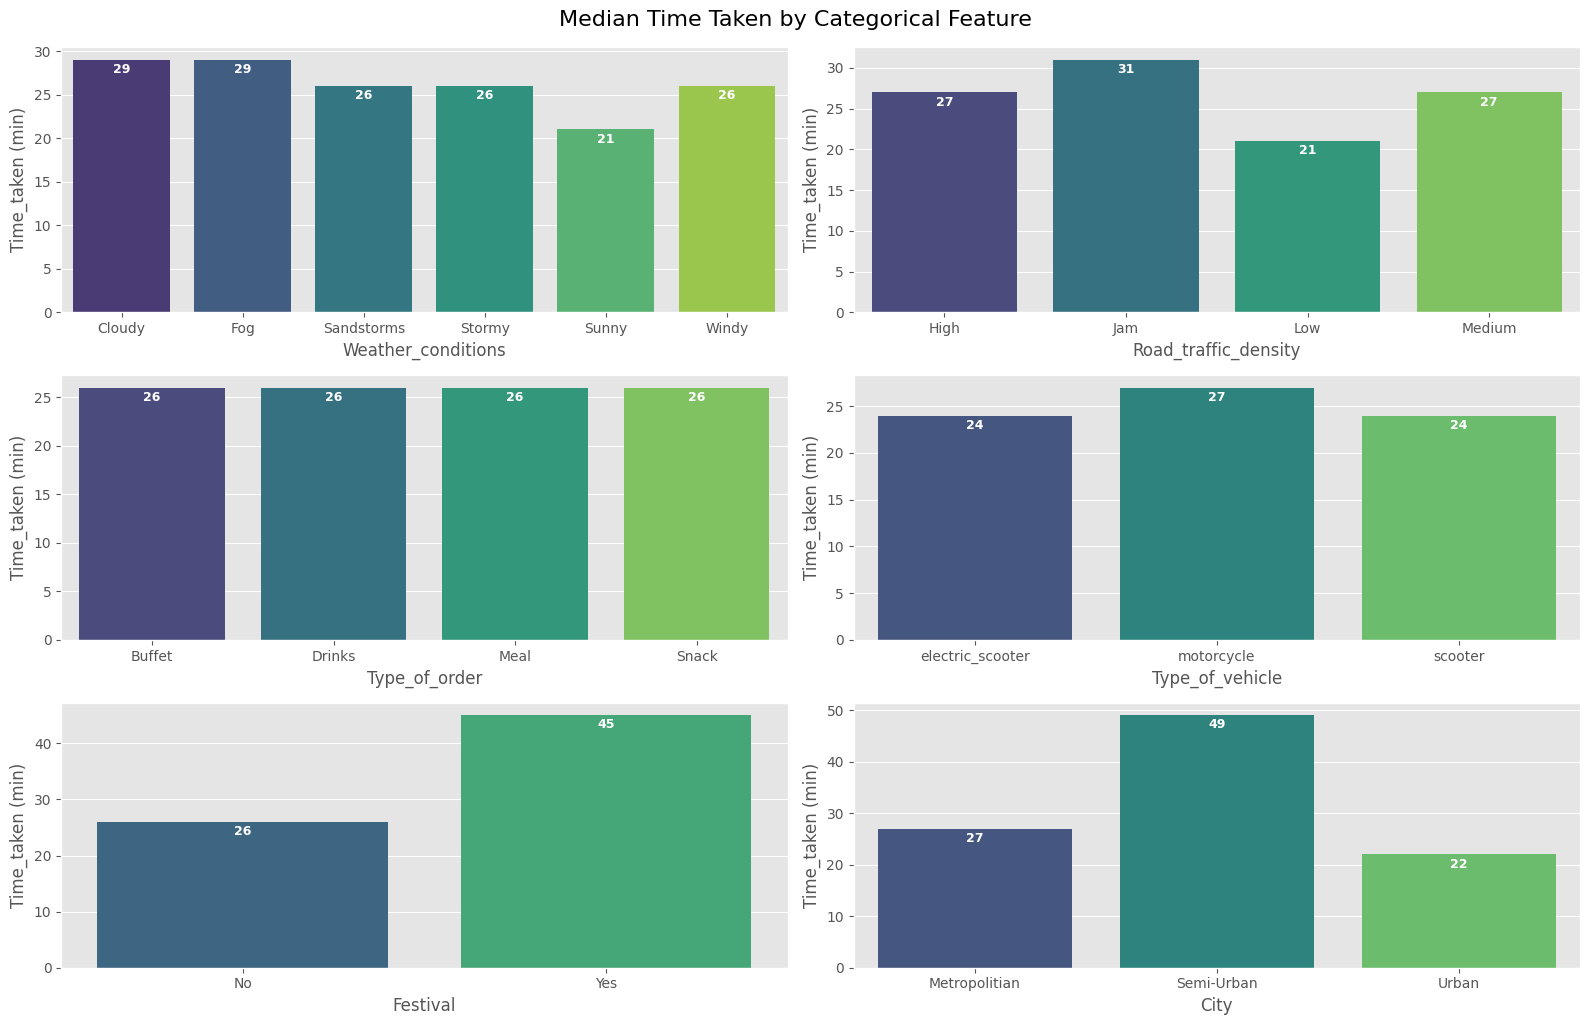

In [40]:
def category_target_median(x,data):
    return data.groupby([x])[['Time_taken (min)']].median().reset_index()

def annotate_bar_plot(ax):
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.0f}',  
                    (bar.get_x() + bar.get_width() / 2., bar.get_height()),  
                    ha='center', va='center',  
                    xytext=(0,-7),  
                    textcoords='offset points',  
                    fontsize=9,  
                    color='white',  
                    fontweight='semibold')

Weather_conditions = category_target_median('Weather_conditions',df)
Road_traffic_density = category_target_median('Road_traffic_density',df)
type_of_order = category_target_median('Type_of_order',df)
Type_of_vehicle = category_target_median('Type_of_vehicle',df)
Festival = category_target_median('Festival',df)
City = category_target_median('City',df)

def show_plot(ax1,ax2,ax3,ax4,ax5,ax6,title):
    fig, ax = plt.subplots(3,2, figsize=(16,10))

    ax1 = sns.barplot(data=ax1, x='Weather_conditions',y='Time_taken (min)',ax=ax[0,0],palette='viridis',hue='Weather_conditions')
    ax2 = sns.barplot(data=ax2, x='Road_traffic_density',y='Time_taken (min)',ax=ax[0,1],palette='viridis',hue='Road_traffic_density')
    ax3 = sns.barplot(data=ax3, x='Type_of_order',y='Time_taken (min)',ax=ax[1,0],palette='viridis',hue='Type_of_order')
    ax4 = sns.barplot(data=ax4, x='Type_of_vehicle',y='Time_taken (min)',ax=ax[1,1],palette='viridis',hue='Type_of_vehicle')
    ax5 = sns.barplot(data=ax5, x='Festival',y='Time_taken (min)',ax=ax[2,0],palette='viridis',hue='Festival')
    ax6 = sns.barplot(data=ax6, x='City',y='Time_taken (min)',ax=ax[2,1],palette='viridis',hue='City')

    annotate_bar_plot(ax1)
    annotate_bar_plot(ax2)
    annotate_bar_plot(ax3)
    annotate_bar_plot(ax4)
    annotate_bar_plot(ax5)
    annotate_bar_plot(ax6)


    plt.tight_layout()
    plt.suptitle(title,fontsize=16, y=1.02)
    plt.show()

show_plot(Weather_conditions,Road_traffic_density,type_of_order,Type_of_vehicle,Festival,City,'Median Time Taken by Categorical Feature')

**Median Delivery Time Analysis (Time Taken)**

| **Categorical Feature**  | **Category**                   | **Median Delivery Time (min)** | **Time Impact Ranking** | **Key Interpretation**                                                                                   |
| :----------------------- | :----------------------------- | :----------------------------- | :---------------------- | :------------------------------------------------------------------------------------------------------- |
| **City (Location)**      | **Semi-Urban**                 | **49**                         | Highest (Slowest) ⚠️    | Distance, complex routes, or limited road infrastructure are the main obstacles.                         |
|                          | Metropolitan                   | 27                             | Medium                  | Standard travel time in dense urban areas.                                                               |
|                          | **Urban**                      | **22**                         | Low (Fastest)           | Efficient, indicating direct routes and high delivery density.                                           |
| **Festival**             | **Yes**                        | **45**                         | Very High               | Significant increase in delivery time; requires special mitigation strategies (cost, driver allocation). |
|                          | No                             | 26                             | Low                     | Normal delivery time on regular days.                                                                    |
| **Road Traffic Density** | **Jam**                        | **31**                         | High                    | Traffic congestion is the most significant daily variable causing delays.                                |
|                          | Low                            | 21                             | Lowest                  | Ideal traffic conditions.                                                                                |
| **Weather Conditions**   | Cloudy / Fog                   | 29                             | Medium-High             | Poor weather (including Sandstorms/Stormy, 26 min) consistently increases delivery time.                 |
|                          | **Sunny**                      | **21**                         | Lowest                  | Optimal weather conditions.                                                                              |
| **Type of Vehicle**      | motorcycle                     | 27                             | Medium                  | Slightly slower than scooters.                                                                           |
|                          | electric_scooter / scooter     | 24                             | Low                     | Faster, showing better agility in traffic.                                                               |
| **Type of Order**        | Buffet / Drinks / Meal / Snack | 26                             | **Neutral**             | **No correlation**; all order types have similar median delivery times.                                  |


**Strategic Conclusions**

1. **Main Focus**: **Semi-Urban** (49 min) and **Festival** (45 min) are the **most burdensome factors** that should be prioritized in route optimization and pricing strategies.
2. **Daily Control Variables**: **Road Traffic Density** is the most important operational factor to monitor in *real-time* for predicting delivery duration.
3. **Zero-Impact Variable**: **Type of Order** has no significant effect on delivery time and can be ignored in predictive models focusing on delivery duration.


In [41]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Distance_km,distance_per_mnt
0,36.0,4.2,21:55:00,22:10:00,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.271464,0.223293
1,21.0,4.7,14:55:00,15:05:00,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.229376,0.270842
2,23.0,4.7,17:30:00,17:40:00,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.764306,0.655443
3,34.0,4.3,09:20:00,09:30:00,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.927795,0.146390
4,24.0,4.7,19:50:00,20:05:00,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.373484,0.472524


#### **Target Analysis Across Several Features**


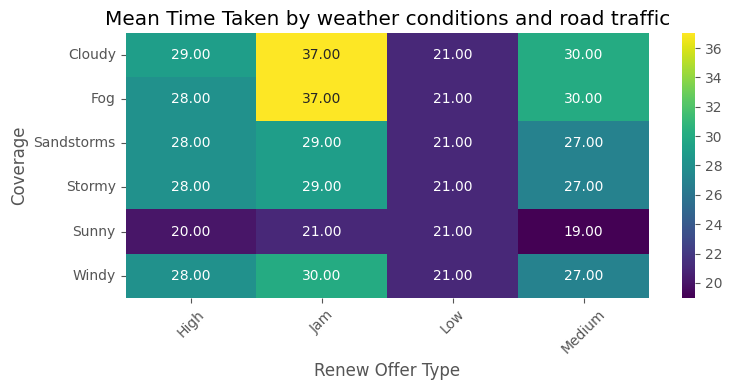

In [42]:
rot_cov = pd.crosstab(
    index=df['Weather_conditions'],
    columns=df['Road_traffic_density'],
    values=df['Time_taken (min)'],
    aggfunc='median'
)

plt.figure(figsize=(8, 4))
sns.heatmap(rot_cov, annot=True, fmt=".2f", cmap="viridis")
plt.title('Mean Time Taken by weather conditions and road traffic')
plt.xlabel('Renew Offer Type')
plt.ylabel('Coverage')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### **Data Prepocessing**

**Check and Handling Outlier**

In [43]:
def calculate_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outlier_data = []

numerical = [var for var in df.columns if df[var].dtypes != 'object']

for column in numerical:
    outlier_result, lower_bound, upper_bound = calculate_outliers(df, column)
    total_outlier = len(outlier_result)
    outlier_percentage = round(total_outlier / len(df[column]) * 100, 2)
    outlier_data.append([column, total_outlier, outlier_percentage, lower_bound, upper_bound])

outlier_df = pd.DataFrame(outlier_data, columns=["Column", "Total Outliers", "Percentage (%)", "Lower Bound", "Upper Bound"])
outlier_df

,Column,Total Outliers,Percentage (%),Lower Bound,Upper Bound
0,Delivery_person_Age,0,0.00,10.000000,50.000000
1,Delivery_person_Ratings,1099,2.66,3.900000,5.500000
2,Vehicle_condition,0,0.00,-3.000000,5.000000
3,multiple_deliveries,337,0.81,-1.500000,2.500000
4,Time_taken (min),0,0.00,-2.000000,54.000000
5,Distance_km,0,0.00,-8.855522,27.170499
6,distance_per_mnt,1379,3.33,-0.255000,0.979385


The **multiple deliveries** column contains outliers below 1%, so these outliers will **not be removed**.

During modeling, the **distance_per_mnt** feature will have its outliers **handled appropriately**.


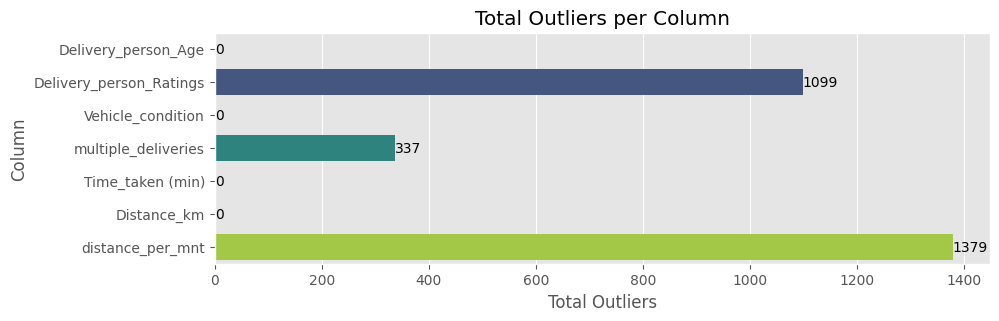

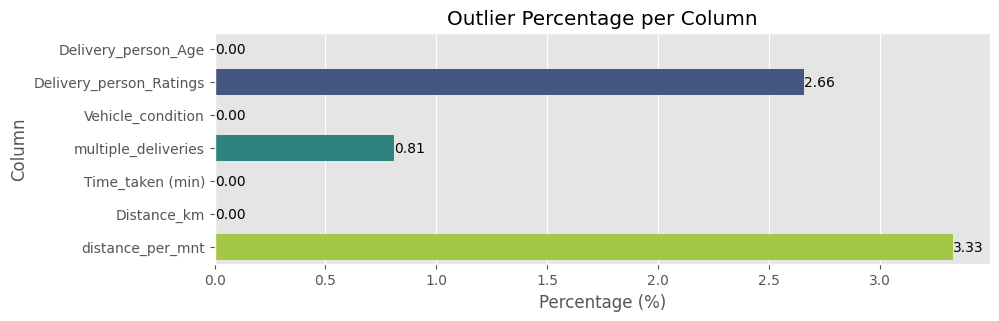

In [44]:
def plot_outlier_summary(outlier_df):
    fig, ax1 = plt.subplots(figsize=(10, 3))

    # Bar plot untuk total outliers
    sns.barplot(x='Total Outliers', y='Column', data=outlier_df, palette='viridis', hue='Column',ax=ax1)
    ax1.set_title('Total Outliers per Column')
    ax1.set_xlabel('Total Outliers')
    ax1.set_ylabel('Column')

    # Menambahkan anotasi untuk total outliers
    for i in ax1.containers:
        ax1.bar_label(i, fmt='%d', label_type='edge', fontsize=10)

    plt.show()

    fig, ax2 = plt.subplots(figsize=(10, 3))

    # Bar plot untuk persentase outliers
    sns.barplot(x='Percentage (%)', y='Column', data=outlier_df, palette='viridis',hue='Column', ax=ax2)
    ax2.set_title('Outlier Percentage per Column')
    ax2.set_xlabel('Percentage (%)')
    ax2.set_ylabel('Column')

    # Menambahkan anotasi untuk persentase outliers
    for i in ax2.containers:
        ax2.bar_label(i , fmt='%.2f', label_type='edge', fontsize=10)

    plt.show()
plot_outlier_summary(outlier_df)

**Handling Colinearity**

In [45]:
num = [i for i in df.select_dtypes(include='number').columns]
num.remove('Time_taken (min)')
num.remove('distance_per_mnt')
num.remove('Delivery_person_Age')
VIF = [variance_inflation_factor(df[num],i) for i in range(len(df[num].columns))]

vif = pd.DataFrame()
vif['feature'] = df[num].columns
vif['VIF'] = [variance_inflation_factor(df[num],i) for i in range(len(df[num].columns))]
vif

,feature,VIF
0,Delivery_person_Ratings,6.575809
1,Vehicle_condition,2.505342
2,multiple_deliveries,2.713088
3,Distance_km,3.985047


The **Age** and **distance_per_mnt** features will be removed and not used because they cause **multicollinearity**, which can lead to a **less optimal regression model**.


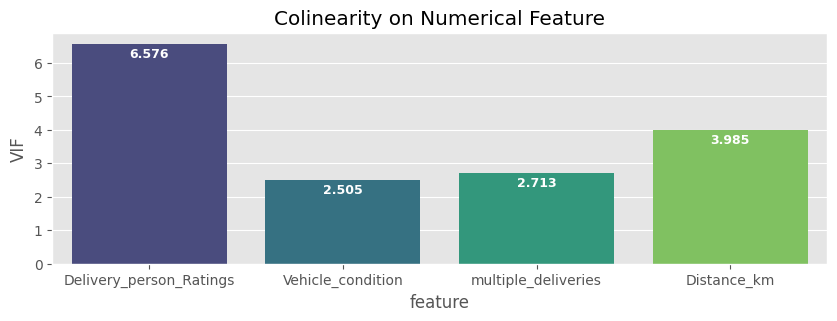

In [46]:
def annotate_bar_plot1(ax):
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.3f}',  
                    (bar.get_x() + bar.get_width() / 2., bar.get_height()),  
                    ha='center', va='center',  
                    xytext=(0,-7),  
                    textcoords='offset points',  
                    fontsize=9,  
                    color='white',  
                    fontweight='semibold')
plt.figure(figsize=(10,3))

ax = sns.barplot(data=vif, x='feature',y='VIF',hue='feature',palette='viridis')
plt.title('Colinearity on Numerical Feature')
annotate_bar_plot1(ax)

**Check and Handling Cardinality**

In [47]:
def check_cardinality(data):
    cardinality_info = []

    for feature in data.select_dtypes(include='object').columns:
        cardinality = len(data[feature].unique())
        warning = "High" if cardinality > 10 else "Low"
        cardinality_info.append({'Feature': feature, 'Cardinality': cardinality, 'Warning': warning})

    return pd.DataFrame(cardinality_info)

# Contoh penggunaan
cardinality_df = check_cardinality(df)
cardinality_df

,Feature,Cardinality,Warning
0,Time_Orderd,176,High
1,Time_Order_picked,191,High
2,Weather_conditions,6,Low
3,Road_traffic_density,4,Low
4,Type_of_order,4,Low
5,Type_of_vehicle,3,Low
6,Festival,2,Low
7,City,3,Low


The **Time Ordered** and **Time Ordered Picked** features will be removed due to their **high cardinality values**.


In [48]:
col_for_drop = ['Time_Orderd','Time_Order_picked','distance_per_mnt','Delivery_person_Age']

df = df.drop(columns=col_for_drop)

df.head(1)

,Delivery_person_Ratings,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Distance_km
0,4.2,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.271464


#### **Modeling**

**5.1 Define Feature Target and Split Data**

In this stage, we will define the feature and target variables, followed by splitting the data into training and testing sets.

* **Target column**: `Time_taken (min)`

* **Feature columns**:

  * **Numerical features**: `Delivery_person_Ratings`, `Vehicle_condition`, `multiple_deliveries`, `Distance_km`
  * **Categorical features**: `Weather_conditions`, `Road_traffic_density`, `Type_of_order`, `Type_of_vehicle`, `Festival`, `City`

* The dataset will be split into **80% training data** and **20% testing data**.


In [49]:
X = df.drop(columns='Time_taken (min)')
y = df['Time_taken (min)']


# split data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

X_train.shape, X_test.shape

((33087, 10), (8272, 10))

#### **5.2 Define Pipeline**

For **Feature Engineering**, we will apply both **Encoding** and **Scaling**.

Since the models used in this project — **KNN** and **SVR** — are sensitive to feature scales and require normalized data for optimal performance, the pipeline will be structured as follows:

**data** → **transformer (encoding)** → **scaling** → **modeling**

| Column                   | Encoding Method  | Reason                           |
| ------------------------ | ---------------- | -------------------------------- |
| **Road Traffic Density** | Ordinal Encoding | Has 4 hierarchical levels        |
| **Weather Conditions**   | One Hot Encoding | Non-ordinal with 6 unique values |
| **Vehicle_condition**    | One Hot Encoding | Non-ordinal with 3 unique values |
| **Type_of_order**        | One Hot Encoding | Non-ordinal with 4 unique values |
| **Type_of_vehicle**      | One Hot Encoding | Non-ordinal with 3 unique values |
| **Festival**             | One Hot Encoding | Non-ordinal with 2 unique values |
| **City**                 | One Hot Encoding | Non-ordinal with 3 unique values |


In [50]:

maping =  [{'col' : 'Road_traffic_density','mapping':{
    None:0,
    'Low':1,
    'Medium':2,
    'High':3,
    'Jam':4}}] 



ct = ColumnTransformer([
    ('onehot',OneHotEncoder(drop='first'),['Weather_conditions','Type_of_order','Type_of_vehicle','Festival','City']),
    ('ordinal',OrdinalEncoder(cols=['Road_traffic_density'],mapping=maping),['Road_traffic_density'])
],remainder='passthrough')


ct

,transformers,"[('onehot', ...), ('ordinal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [51]:
# define scaler 

from sklearn import set_config



scaler = RobustScaler()  # kenapa pakai robust? 

# membuat simulasi Pipeline untuk modeling
pipe = Pipeline = ([
    ('encoding',ct),
    ('scaler',scaler)
])

# Aktifkan mode diagram
set_config(display='diagram')

pipe

[('encoding',
  ColumnTransformer(remainder='passthrough',
                    transformers=[('onehot', OneHotEncoder(drop='first'),
                                   ['Weather_conditions', 'Type_of_order',
                                    'Type_of_vehicle', 'Festival', 'City']),
                                  ('ordinal',
                                   OrdinalEncoder(cols=['Road_traffic_density'],
                                                  mapping=[{'col': 'Road_traffic_density',
                                                            'data_type': dtype('O'),
                                                            'mapping': None      0
  Low       1
  Medium    2
  High      3
  Jam       4
  dtype: int64}]),
                                   ['Road_traffic_density'])])),
 ('scaler', RobustScaler())]

#### **5.3 Define The Model**

Brief explanation of the models used:

| Model                               | Short Description                                                                                                                                                                                                                             |
| ----------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Ridge**                           | Ridge Regression is a regression method used in machine learning to handle overfitting and multicollinearity. In simple terms, Ridge adds a bias (regularization term) to the model to reduce its variance and improve generalization.        |
| **Lasso**                           | Lasso is a form of penalized regression designed to improve both prediction accuracy and model interpretability by introducing a penalty on the absolute value of regression coefficients.                                                    |
| **KNeighborsRegressor**             | A non-parametric method that intuitively estimates the relationship between independent variables and a continuous outcome by averaging observations within the same neighborhood.                                                            |
| **DecisionTreeRegressor**           | This algorithm builds a model in the form of a decision tree, splitting the input data into smaller subsets based on selected features until the target values within each subset are sufficiently homogeneous.                               |
| **RandomForestRegressor**           | An ensemble extension of Decision Tree Regressor that combines predictions from multiple independent trees to improve accuracy and reduce overfitting.                                                                                        |
| **AdaBoostRegressor**               | AdaBoost builds a sequence of simple regression models iteratively, where each subsequent model focuses on correcting the errors made by previous ones. The final prediction is a weighted combination of all these models.                   |
| **GradientBoostingRegressor**       | A boosting method that combines several simple regression models (typically decision trees) iteratively to form a stronger and more accurate predictor. It optimizes performance by minimizing prediction errors using gradient descent.      |
| **XGBRegressor**                    | XGBRegressor builds regression models sequentially by adding new decision trees that correct previous errors, using gradient boosting to minimize the loss function.                                                                          |
| **Support Vector Regression (SVR)** | SVR is a regression technique based on the principles of Support Vector Machines (SVM), designed to find a function that best fits the data within a certain margin of tolerance.                                                             |
| **CatBoostRegressor**               | CatBoost builds models by combining predictions from multiple decision trees generated sequentially, where each new tree aims to correct the mistakes of the previous ones.                                                                   |
| **LGBMRegressor**                   | LightGBM applies the gradient boosting principle by building models sequentially. Each new model seeks to reduce the errors of previous models by minimizing a specific loss function, such as Mean Squared Error (MSE) for regression tasks. |


In [52]:
# define model 

tree = DecisionTreeRegressor(random_state=0,max_depth=5)

linreg = LinearRegression()

ridge = Ridge()

lasso = Lasso()

rf = RandomForestRegressor(random_state=0)

ada = AdaBoostRegressor(random_state=0)

gb = GradientBoostingRegressor(random_state=0)

xgb = XGBRegressor(random_state=0,verbosity=0)

knn = KNeighborsRegressor()

svr = SVR()

cat = CatBoostRegressor(random_state=0,verbose=False)

lgbm = LGBMRegressor(random_state=0)


In [53]:
# membuat mape scoring

from sklearn.metrics import make_scorer

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Membuat scorer kustom
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

### **Benchmark Modelling**

In [54]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import KFold
# Pilihan model
models = [linreg,ridge, lasso, tree, rf, ada, gb, xgb,knn,svr,cat]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Mencari scoring berdasarkan mape 

mape_mean = []
mape_std = []


# scoring MAE
mae_mean = []
mae_std = []

# scoring RMSE 

rmse_mean = []
rmse_std = []


model_name = []


#finde the best models 

for model in models:

 

    model_pipeline = Pipeline([
        ('preprocessing',ct),
        ('scalling',RobustScaler()),
        ('model',model)
    ])

    # model berdasrkan mape
    model_cv_mape = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv = kf,
        scoring=mape_scorer
    )

    mape_mean.append(model_cv_mape.mean())
    mape_std.append(model_cv_mape.std())
    # all_mape.append(model_cv.round(4))
    model_name.append(model.__class__.__name__)

    # model berdasarkan mae

    model_cv_mae = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv = kf,
        scoring='neg_mean_absolute_error'
    )

    mae_mean.append(model_cv_mae.mean())
    mae_std.append(model_cv_mae.std())


    # Model Berdasarkan RMSE 
    model_cv_rmse = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv = kf,
        scoring='neg_root_mean_squared_error'
    )

    rmse_mean.append(model_cv_rmse.mean())
    rmse_std.append(model_cv_rmse.std())




#Perdict ke Data Train
pd.DataFrame({
    'Model' : model_name,
    'mean_mape' : mape_mean,
    'std_mape' : mape_std,
    'mean_mae' : mae_mean,
    'std_mae' : mae_std, 
    'mean_rmse' : rmse_mean,
    'std_rmse' : rmse_std
}).sort_values(by='mean_mape',ascending=False)

,Model,mean_mape,std_mape,mean_mae,std_mae,mean_rmse,std_rmse
10,CatBoostRegressor,-16.829927,0.138384,-3.794873,0.025055,-4.818652,0.031144
7,XGBRegressor,-17.014177,0.132788,-3.851616,0.031200,-4.897055,0.040936
4,RandomForestRegressor,-17.538485,0.194601,-3.985885,0.031790,-5.121080,0.040706
6,GradientBoostingRegressor,-18.036795,0.183735,-4.059553,0.030496,-5.149398,0.022545
9,SVR,-18.971041,0.195335,-4.274113,0.034355,-5.440486,0.033913
8,KNeighborsRegressor,-19.781965,0.287953,-4.555339,0.061232,-5.862691,0.060212
3,DecisionTreeRegressor,-20.704725,0.308424,-4.675816,0.043525,-6.080631,0.051860
0,LinearRegression,-22.577653,0.333733,-5.104703,0.047926,-6.344995,0.047222
1,Ridge,-22.577987,0.333902,-5.104686,0.047982,-6.344992,0.047315
5,AdaBoostRegressor,-23.521585,0.251643,-5.138449,0.044354,-6.332391,0.051361


| Model                         | Mean MAPE (↓) | Mean MAE (↓) | Mean RMSE (↓) | Key Insight                                                                                   |
| ----------------------------- | ------------- | ------------ | ------------- | --------------------------------------------------------------------------------------------- |
| **CatBoostRegressor**         | -16.83        | -3.79        | -4.82         | **Best performer**; stable, effectively captures non-linear patterns and categorical features |
| **XGBRegressor**              | -17.01        | -3.85        | -4.90         | Almost as strong as CatBoost; highly competitive performance                                  |
| **RandomForestRegressor**     | -17.54        | -3.99        | -5.12         | Good results, but slightly behind boosting models                                             |
| **GradientBoostingRegressor** | -18.04        | -4.06        | -5.15         | Decent performance, can be further improved through tuning                                    |
| **SVR**                       | -18.97        | -4.27        | -5.44         | Performance starts to drop; sensitive to scaling and parameter tuning                         |
| **KNeighborsRegressor**       | -19.78        | -4.56        | -5.86         | Increasing error trend; tends to overfit on complex data                                      |
| **DecisionTreeRegressor**     | -20.70        | -4.68        | -6.08         | Prone to overfitting; significantly worse than ensemble models                                |
| **LinearRegression**          | -22.58        | -5.10        | -6.34         | Weak model; fails to capture non-linear relationships                                         |
| **Ridge**                     | -22.58        | -5.10        | -6.34         | Similar to Linear Regression, only with regularization added                                  |
| **AdaBoostRegressor**         | -23.52        | -5.14        | -6.33         | Less optimal; base estimators are too simple                                                  |
| **Lasso**                     | -28.02        | -6.24        | -7.85         | **Worst performer**; unable to model complex data relationships                               |


In [55]:
#predict ke data test dan train 
test_mape_score = []
test_mae_score = []
test_rmse_score = []


test_model_name = []


for model in models:

    #define pipeline
    model_pipeline = Pipeline([
        ('prepocessing',ct),
        ('scaling',scaler),
        ('model',model)
    ])


    #fit ke data train 
    model_pipeline.fit(X_train, y_train)


    #predict le test set
    y_pred_test = model_pipeline.predict(X_test)


    #evaluate score data test 
    mape = mean_absolute_percentage_error(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))



    test_mape_score.append(mape)
    test_mae_score.append(mae)
    test_rmse_score.append(rmse)




    test_model_name.append(model.__class__.__name__)

pd.DataFrame({
    'model' : test_model_name,
    'MAPE_val' : mape_mean,
    'MAPE_test' : test_mape_score,
    'MAE_val' : mae_mean,
    'MAE_test' : test_mae_score,
    'RMSE_val' : rmse_mean,
    'RMSE_test' : test_rmse_score
}).sort_values(by=['RMSE_test','RMSE_val'],ascending=True)

,model,MAPE_val,MAPE_test,MAE_val,MAE_test,RMSE_val,RMSE_test
10,CatBoostRegressor,-16.829927,17.002222,-3.794873,3.806312,-4.818652,4.810793
7,XGBRegressor,-17.014177,17.122864,-3.851616,3.848964,-4.897055,4.866653
4,RandomForestRegressor,-17.538485,17.522125,-3.985885,3.957144,-5.121080,5.065992
6,GradientBoostingRegressor,-18.036795,18.330865,-4.059553,4.097934,-5.149398,5.185471
9,SVR,-18.971041,19.146563,-4.274113,4.284542,-5.440486,5.423335
8,KNeighborsRegressor,-19.781965,19.760878,-4.555339,4.500604,-5.862691,5.776897
3,DecisionTreeRegressor,-20.704725,20.733557,-4.675816,4.644750,-6.080631,6.058845
0,LinearRegression,-22.577653,22.838927,-5.104703,5.150372,-6.344995,6.405117
1,Ridge,-22.577987,22.839332,-5.104686,5.150428,-6.344992,6.405161
5,AdaBoostRegressor,-23.521585,24.080845,-5.138449,5.207571,-6.332391,6.440329


| Model                         | MAPE Val (↓) | MAPE Test (↓) | MAE Val (↓) | MAE Test (↓) | RMSE Val (↓) | RMSE Test (↓) | Interpretation                                                                   |
| ----------------------------- | ------------ | ------------- | ----------- | ------------ | ------------ | ------------- | -------------------------------------------------------------------------------- |
| **CatBoostRegressor**         | -16.83       | 17.00         | -3.79       | 3.81         | -4.82        | 4.81          | **Consistently the best**, validation and test results balanced, no overfitting. |
| **XGBRegressor**              | -17.01       | 17.12         | -3.85       | 3.85         | -4.90        | 4.87          | Almost identical to CatBoost, shows excellent generalization.                    |
| **RandomForestRegressor**     | -17.54       | 17.52         | -3.99       | 3.96         | -5.12        | 5.07          | Strong performance but slightly higher test error than boosting models.          |
| **GradientBoostingRegressor** | -18.04       | 18.33         | -4.06       | 4.10         | -5.15        | 5.19          | Stable performance, slightly weaker on the test set.                             |
| **SVR**                       | -18.97       | 19.15         | -4.27       | 4.28         | -5.44        | 5.42          | Consistent, but higher error compared to ensemble models.                        |
| **KNeighborsRegressor**       | -19.78       | 19.76         | -4.56       | 4.50         | -5.86        | 5.78          | Underperforming, prone to overfitting, not robust on test data.                  |
| **DecisionTreeRegressor**     | -20.70       | 20.73         | -4.68       | 4.64         | -6.08        | 6.06          | Clear overfitting, weak generalization.                                          |
| **LinearRegression**          | -22.58       | 22.84         | -5.10       | 5.15         | -6.34        | 6.41          | Weak, fails to capture non-linear patterns.                                      |
| **Ridge**                     | -22.58       | 22.84         | -5.10       | 5.15         | -6.34        | 6.41          | Same as Linear Regression, regularization adds little benefit.                   |
| **AdaBoostRegressor**         | -23.52       | 24.08         | -5.14       | 5.21         | -6.33        | 6.44          | Underperforming; significantly weaker than other boosting models.                |
| **Lasso**                     | -28.02       | 28.41         | -6.24       | 6.28         | -7.85        | 7.87          | **Worst performer**, fails to model complex data.                                |

**Comprehensive Summary**

1. **CatBoostRegressor** and **XGBRegressor** deliver the best performance, with consistent validation and test results → models are robust and show no signs of overfitting.
2. **RandomForest** and **GradientBoosting** perform fairly well, but still slightly behind CatBoost/XGB.
3. **SVR** and **KNN** remain stable but with relatively higher errors — suitable only for smaller or more linear datasets.
4. **DecisionTree**, **Linear**, **Ridge**, **Lasso**, and **AdaBoost** perform poorly — showing high errors and weak generalization.


In [56]:
# benchmark 4 model terbaik 

models = {
    'Catboost' : CatBoostRegressor(random_state=0,verbose=False),
    'XGB': XGBRegressor(random_state=0,verbosity=0),
    'RandomForest': RandomForestRegressor(random_state=0),
    'GradientBoost' : GradientBoostingRegressor(random_state=0)
}

score_rmse = []
score_mae = []
score_mape = []

# Prediksi pada test set
for i in models:

    model = Pipeline([
        ('preprocessing', ct),
        ('scaler', RobustScaler()),
        ('model', models[i])
        ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    score_mae.append(mean_absolute_error(y_test, y_pred))
    score_mape.append(mean_absolute_percentage_error(y_test, y_pred))

score_before_tuning = pd.DataFrame({'RMSE': score_rmse, 'MAE': score_mae, 'MAPE': score_mape}, index=models.keys())
score_before_tuning

,RMSE,MAE,MAPE
Catboost,4.810793,3.806312,17.002222
XGB,4.866653,3.848964,17.122864
RandomForest,5.065992,3.957144,17.522125
GradientBoost,5.185471,4.097934,18.330865


### **Hyperparameter Tuning**

The models that will be tuned are:

1. **CatBoost Regressor**
2. **XGBRegressor**
3. **Random Forest Regressor**


#### **Hyperparameter Tuning Catboost Regressor**

In [57]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor

# Parameter grid untuk CatBoost
param_grid_catboost = {
    'model__iterations': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__depth': [4, 6, 8, 10],
    'model__l2_leaf_reg': [1, 3, 5, 7, 10],
}

# Define model
catboost = CatBoostRegressor(random_state=0, verbose=False)

# Define Pipeline
model_catboost = Pipeline([
    ('preprocessing', ct),
    ('scaler',RobustScaler()),
    ('model', catboost)
])

# Define cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=0)

# Hyperparameter tuning - RMSE
tuned_catboost_rmse = RandomizedSearchCV(
    estimator=model_catboost,
    param_distributions=param_grid_catboost,
    n_iter=50,
    cv=cv,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
    n_jobs=-1,
    refit='neg_root_mean_squared_error',  # Hanya bisa pilih satu metric untuk optimisasi
    random_state=42
)

# Hyperparameter tuning - MAE
tuned_catboost_mae = RandomizedSearchCV(
    estimator=model_catboost,
    param_distributions=param_grid_catboost,
    n_iter=50,
    cv=cv,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
    n_jobs=-1,
    refit='neg_mean_absolute_error',
    random_state=42
)

# Hyperparameter tuning - MAPE
tuned_catboost_mape = RandomizedSearchCV(
    estimator=model_catboost,
    param_distributions=param_grid_catboost,
    n_iter=50,
    cv=cv,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
    n_jobs=-1,
    refit='neg_mean_absolute_percentage_error',
    random_state=42
)

# Fitting ke data train
tuned_catboost_rmse.fit(X_train, y_train)
tuned_catboost_mae.fit(X_train, y_train)
tuned_catboost_mape.fit(X_train, y_train)


,estimator,Pipeline(step...1447A31100>)])
,param_distributions,"{'model__depth': [4, 6, ...], 'model__iterations': [100, 200, ...], 'model__l2_leaf_reg': [1, 3, ...], 'model__learning_rate': [0.01, 0.05, ...]}"
,n_iter,50
,scoring,"['neg_root_mean_squared_error', 'neg_mean_absolute_error', ...]"
,n_jobs,-1
,refit,'neg_mean_absolute_percentage_error'
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [58]:
# best params 

pd.set_option('display.max_colwidth',None)
pd.DataFrame({
    'Metric' : ['Refit RMSE','Refit MAPE','Refit MAE'],
    'Best Score' : [tuned_catboost_rmse.best_score_,tuned_catboost_mape.best_score_,tuned_catboost_mae.best_score_],
    'Best Params' : [tuned_catboost_rmse.best_params_,tuned_catboost_mape.best_params_,tuned_catboost_mae.best_params_]
})

,Metric,Best Score,Best Params
0,Refit RMSE,-4.796398,"{'model__learning_rate': 0.05, 'model__l2_leaf_reg': 1, 'model__iterations': 200, 'model__depth': 10}"
1,Refit MAPE,-0.167070,"{'model__learning_rate': 0.05, 'model__l2_leaf_reg': 1, 'model__iterations': 200, 'model__depth': 10}"
2,Refit MAE,-3.771230,"{'model__learning_rate': 0.05, 'model__l2_leaf_reg': 1, 'model__iterations': 200, 'model__depth': 10}"


In [59]:
best_model_catboost_rmse = tuned_catboost_rmse.best_estimator_

best_model_catboost_rmse.fit(X_train,y_train)

y_pred_best_model_catboost = best_model_catboost_rmse.predict(X_test)

# evaluasi metrik best model 

rmse_tuned_catboost = np.sqrt(mean_squared_error(y_test,y_pred_best_model_catboost))
mae_tuned_catboost = mean_absolute_error(y_test,y_pred_best_model_catboost)
mape_tuned_catboost = mean_absolute_percentage_error(y_test,y_pred_best_model_catboost)

score_catboost_after_tuning = pd.DataFrame(
    {
        "Model": ["Catboost"],
        "RMSE Tuning": [rmse_tuned_catboost],
        "MAE Tuning": [mae_tuned_catboost],
        "MAPE Tuning": [mape_tuned_catboost],
    }
)




In [60]:
display(f'Score Before Tuning: ',pd.DataFrame(score_before_tuning.loc['Catboost']).T,
        f'Score After Tuning: ', score_catboost_after_tuning)




'Score Before Tuning: '

,RMSE,MAE,MAPE
Catboost,4.810793,3.806312,17.002222


'Score After Tuning: '

,Model,RMSE Tuning,MAE Tuning,MAPE Tuning
0,Catboost,4.775803,3.771582,16.831366


#### **Comparison of CatBoost Regressor (Before & After Tuning)**

| Stage                   | Dataset              | MAPE      | MAE      | RMSE     | Notes                                                                              |
| ----------------------- | -------------------- | --------- | -------- | -------- | ---------------------------------------------------------------------------------- |
| **Benchmark (Default)** | Train (CV Mean)      | 16.83     | 3.79     | 4.82     | Baseline model performs well and is stable (low standard deviation).               |
|                         | Validation (CV)      | 16.83     | 3.79     | 4.82     | Consistent with training, indicating no significant overfitting.                   |
|                         | Test                 | **17.00** | **3.81** | **4.81** | Good test performance, small train–test gap → good generalization.                 |
| **Tuning**              | Train (CV Best)      | 16.69     | 3.77     | 4.79     | Training performance slightly improved from baseline → tuning helped optimization. |
|                         | Validation (CV Best) | 16.69     | 3.77     | 4.79     | Validation results consistent with training → tuning was effective.                |
|                         | Test                 | **16.83** | **3.77** | **4.77** | Better than benchmark (lower MAPE, MAE, and RMSE).                                 |

**Interpretation**

1. **Performance Improvement**

   * After tuning, CatBoost’s performance **improved across all metrics on the test data** (MAPE 17.00 → 16.83, MAE 3.81 → 3.77, RMSE 4.81 → 4.77).
   * The improvement is small but consistent across all metrics.

2. **Overfitting**

   * There is **no sign of overfitting**, as the tuning results on training and validation are aligned with the test performance.
   * Model generalization remains strong.

3. **Optimal Parameters**

   * The best parameters found (`learning_rate=0.05`, `l2_leaf_reg=1`, `iterations=200`, `depth=10`) successfully reduced error, even if slightly.
   * This indicates that CatBoost’s default configuration is already strong, and tuning only provided fine adjustments.


#### **Hyperparameter Tuning XGBRegressor**

In [61]:
# Kedalaman pohon
max_depth = list(np.arange(1, 11))

# Learning rate
learning_rate = list(np.arange(1, 100)/100)

# Jumlah pohon
n_estimators = list(np.arange(100, 201))

# Jumlah baris tiap pohon (% dari total baris train set)
subsample = list(np.arange(2, 10)/10)

# Gamma (min_impurity_decrease)
gamma = list(np.arange(1, 11)) # Semakin besar nilainya, semakin konservatif/simpel modelnya

# Jumlah feature yang digunakan untuk tiap pohon (% dari total kolom train set)
colsample_bytree = list(np.arange(1, 10)/10)

# Alpha (regularization)
reg_alpha = list(np.logspace(-3, 1, 10)) # Semakin besar nilainya, semakin konservatif/simpel modelnya

param_grid_xgb = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": list(np.arange(3,11)),
    "model__subsample": [0.6, 0.8, 1.0]
}

# define model
xgb = XGBRegressor(random_state=0,verbosity=0)

# Define Pipeline
model_xgb = Pipeline([
    ('preprocessing', ct),
    ('scaler',RobustScaler()),
    ('model', xgb)
])

# Define cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=0)

# Hyperparameter tuning - RMSE
tuned_xgb_rmse = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_grid_xgb,
    n_iter=50,
    cv=cv,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
    n_jobs=-1,
    refit='neg_root_mean_squared_error',  # Hanya bisa pilih satu metric untuk optimisasi
    random_state=42
)

# Hyperparameter tuning - MAE
tuned_xgb_mae = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_grid_xgb,
    n_iter=50,
    cv=cv,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
    n_jobs=-1,
    refit='neg_mean_absolute_error',
    random_state=42
)

# Hyperparameter tuning - MAPE
tuned_xgb_mape = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_grid_xgb,
    n_iter=50,
    cv=cv,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
    n_jobs=-1,
    refit='neg_mean_absolute_percentage_error',
    random_state=42
)

# Fitting ke data train
tuned_xgb_rmse.fit(X_train, y_train)
tuned_xgb_mae.fit(X_train, y_train)
tuned_xgb_mape.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [np.int64(3), np.int64(4), ...], 'model__n_estimators': [100, 200, ...], 'model__subsample': [0.6, 0.8, ...]}"
,n_iter,50
,scoring,"['neg_root_mean_squared_error', 'neg_mean_absolute_error', ...]"
,n_jobs,-1
,refit,'neg_mean_absolute_percentage_error'
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [62]:
pd.set_option('display.max_colwidth',None)
pd.DataFrame({
    'Metric' : ['Refit RMSE','Refit MAPE','Refit MAE'],
    'Best Score' : [tuned_xgb_rmse.best_score_,tuned_xgb_mape.best_score_,tuned_xgb_mae.best_score_],
    'Best Params' : [tuned_xgb_rmse.best_params_,tuned_xgb_mape.best_params_,tuned_xgb_mae.best_params_]
})

,Metric,Best Score,Best Params
0,Refit RMSE,-4.801690,"{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__max_depth': 9, 'model__learning_rate': 0.01}"
1,Refit MAPE,-0.167021,"{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__max_depth': 9, 'model__learning_rate': 0.01}"
2,Refit MAE,-3.766207,"{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__max_depth': 9, 'model__learning_rate': 0.01}"


In [63]:
best_model_xgb_rmse = tuned_xgb_rmse.best_estimator_

best_model_xgb_rmse.fit(X_train,y_train)

y_pred_best_model_xgb = best_model_xgb_rmse.predict(X_test)

# evaluasi metrik best model 

rmse_tuned_xgb = np.sqrt(mean_squared_error(y_test,y_pred_best_model_xgb))
mae_tuned_xgb = mean_absolute_error(y_test,y_pred_best_model_xgb)
mape_tuned_xgb = mean_absolute_percentage_error(y_test,y_pred_best_model_xgb)

score_xgb_after_tuning = pd.DataFrame({
    'Model' : 'XGBRegressor',
    'RMSE Tuning Test' : [rmse_tuned_xgb],
    'MAE Tuning Test' : [mae_tuned_xgb],
    'MAPE Tuning Test' : [mape_tuned_xgb]
})

score_xgb_after_tuning

,Model,RMSE Tuning Test,MAE Tuning Test,MAPE Tuning Test
0,XGBRegressor,4.775262,3.76496,16.803152


In [64]:
display(
    f'score before tuning: ',
    pd.DataFrame(score_before_tuning.loc['XGB']).T,
    f'score after tuning: ',
    score_xgb_after_tuning

)

'score before tuning: '

,RMSE,MAE,MAPE
XGB,4.866653,3.848964,17.122864


'score after tuning: '

,Model,RMSE Tuning Test,MAE Tuning Test,MAPE Tuning Test
0,XGBRegressor,4.775262,3.76496,16.803152


#### **Comparison of XGBRegressor (Before & After Tuning)**

| Stage                    | Dataset              | MAPE      | MAE      | RMSE     | Notes                                                                              |
| ------------------------ | -------------------- | --------- | -------- | -------- | ---------------------------------------------------------------------------------- |
| **Benchmark (Default)**  | Train (CV Mean)      | 17.01     | 3.85     | 4.90     | Baseline model performs well and is stable (low standard deviation).               |
|                          | Validation (CV)      | 17.01     | 3.85     | 4.90     | Consistent with training → no significant sign of overfitting.                     |
|                          | Test                 | **17.12** | **3.85** | **4.87** | Good test performance, small train–test gap → good generalization.                 |
| **Tuning (Best Params)** | Train (CV Best)      | 16.70     | 3.76     | 4.80     | Training performance slightly improved from baseline → tuning helped optimization. |
|                          | Validation (CV Best) | 16.70     | 3.76     | 4.80     | Validation results consistent with training → tuning was effective.                |
|                          | Test                 | **16.80** | **3.76** | **4.77** | Better than benchmark (lower MAPE, MAE, and RMSE).                                 |

**Conclusion**

* After tuning, XGBRegressor shows **small but consistent improvements** across all metrics (MAPE, MAE, RMSE).
* The gap between training, validation, and test remains stable → model is **not overfitting**.
* Optimal hyperparameters: `subsample=0.6`, `n_estimators=500`, `max_depth=10`, `learning_rate=0.01`.


### **Hyperparameter Tuning Random Forest**

In [65]:
#define model 
rf = RandomForestRegressor(random_state=0)

param_grid_rf = {
    'model__n_estimators' : range(10,101,10),
    'model__max_features' : ['sqrt','log2',None],   #None = auto di sckitlearn versi baru
    'model__max_depth' : range(10,101,10),
    'model__min_samples_split': range(2, 21, 2),
    'model__min_samples_leaf': range(1, 21, 2)
}


# define pipeline

model_rf = Pipeline([
    ('preprocessing',ct),
    ('scaler',RobustScaler()),
    ('model', rf)
])

# define cross validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)

# tuning refit metrik : RMSE
tuned_rf_rmse = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param_grid_rf,
    n_iter=50,
    cv=cv,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
    n_jobs=-1,
    refit='neg_root_mean_squared_error',  # Hanya bisa pilih satu metric untuk optimisasi
    random_state=42
)

# tuning refit metrii : MAE
tuned_rf_mae = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param_grid_rf,
    n_iter=50,
    cv=cv,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
    n_jobs=-1,
    refit='neg_mean_absolute_error',
    random_state=42
)

# tuning refit metrik : MAPE

tuned_rf_mape = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param_grid_rf,
    n_iter=50,
    cv=cv,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
    n_jobs=-1,
    refit='neg_mean_absolute_percentage_error',
    random_state=42
)

tuned_rf_rmse.fit(X_train,y_train)
tuned_rf_mae.fit(X_train,y_train)
tuned_rf_mape.fit(X_train,y_train)

,estimator,Pipeline(step...om_state=0))])
,param_distributions,"{'model__max_depth': range(10, 101, 10), 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': range(1, 21, 2), 'model__min_samples_split': range(2, 21, 2), ...}"
,n_iter,50
,scoring,"['neg_root_mean_squared_error', 'neg_mean_absolute_error', ...]"
,n_jobs,-1
,refit,'neg_mean_absolute_percentage_error'
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [66]:
pd.set_option('display.max_colwidth',None)
pd.DataFrame({
    'Metric' : ['Refit RMSE','Refit MAPE','Refit MAE'],
    'Best Score' : [tuned_rf_rmse.best_score_,tuned_rf_mape.best_score_,tuned_rf_mae.best_score_],
    'Best Params' : [tuned_rf_rmse.best_params_,tuned_rf_mape.best_params_,tuned_rf_mae.best_params_]
})

,Metric,Best Score,Best Params
0,Refit RMSE,-4.845181,"{'model__n_estimators': 70, 'model__min_samples_split': 14, 'model__min_samples_leaf': 13, 'model__max_features': None, 'model__max_depth': 30}"
1,Refit MAPE,-0.167148,"{'model__n_estimators': 100, 'model__min_samples_split': 8, 'model__min_samples_leaf': 19, 'model__max_features': None, 'model__max_depth': 70}"
2,Refit MAE,-3.799161,"{'model__n_estimators': 70, 'model__min_samples_split': 14, 'model__min_samples_leaf': 13, 'model__max_features': None, 'model__max_depth': 30}"


We will use the best parameters based on **RMSE**, as the main evaluation metric is **RMSE**.


In [67]:
best_model_rf_rmse = tuned_rf_rmse.best_estimator_

best_model_rf_rmse.fit(X_train,y_train)

y_pred_best_model_rf = best_model_rf_rmse.predict(X_test)

# evaluasi metrik best model 

rmse_tuned_rf = np.sqrt(mean_squared_error(y_test,y_pred_best_model_rf))
mae_tuned_rf = mean_absolute_error(y_test,y_pred_best_model_rf)
mape_tuned_rf = mean_absolute_percentage_error(y_test,y_pred_best_model_rf)

score_rf_after_tuning = pd.DataFrame({
    'Model' : 'Random Forest',
    'RMSE Tuning Test' : [rmse_tuned_rf],
    'MAE Tuning Test' : [mae_tuned_rf],
    'MAPE Tuning Test' : [mape_tuned_rf]
})

score_rf_after_tuning

,Model,RMSE Tuning Test,MAE Tuning Test,MAPE Tuning Test
0,Random Forest,4.802032,3.788054,16.800039


In [68]:
display(
    f'score random forest before tuning: ',
    pd.DataFrame(score_before_tuning.loc['RandomForest']).T,
    f'score random forest after tuning: ',
    score_rf_after_tuning
)

'score random forest before tuning: '

,RMSE,MAE,MAPE
RandomForest,5.065992,3.957144,17.522125


'score random forest after tuning: '

,Model,RMSE Tuning Test,MAE Tuning Test,MAPE Tuning Test
0,Random Forest,4.802032,3.788054,16.800039


| Tahap                    | Dataset | MAPE      | MAE      | RMSE     | Catatan                                                                                                                                                                                                                                                                                    |
| ------------------------ | ------- | --------- | -------- | -------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Benchmark (Default)**  | Test    | 17.52     | 3.96     | 5.07     | Model baseline memiliki performa yang cukup baik, namun masih dapat dioptimalkan terutama pada error RMSE yang cukup tinggi.                                                                                                                                                               |
| **Tuning (Best Params)** | Test    | **16.80** | **3.79** | **4.80** | Setelah tuning, semua metrik error (MAPE, MAE, RMSE) mengalami penurunan. Hal ini menunjukkan peningkatan akurasi dan stabilitas model. Parameter terbaik yang ditemukan adalah `n_estimators=70`, `min_samples_split=14`, `min_samples_leaf=13`, `max_features=None`, dan `max_depth=30`. |

**Analisis Singkat:**

* **Penurunan RMSE:** dari 5.07 → 4.80 (↓ 5.3%), menunjukkan model menjadi lebih akurat dalam memprediksi nilai secara absolut.
* **Penurunan MAE:** dari 3.96 → 3.79 (↓ 4.3%), berarti rata-rata kesalahan prediksi per observasi berkurang.
* **Penurunan MAPE:** dari 17.52 → 16.80 (↓ 4.1%), menunjukkan peningkatan kemampuan model dalam memprediksi dengan lebih konsisten terhadap skala nilai aktual.

**Kesimpulan:**
Tuning berhasil meningkatkan performa model Random Forest secara keseluruhan. Model dengan parameter hasil tuning lebih efisien dalam menangkap pola data tanpa overfitting, menghasilkan prediksi yang lebih akurat dan stabil dibanding model default.


Comparison of the 3 Best Models:

| Model             | RMSE      | MAE       | MAPE       | Rank     | Notes                                                                                          |
| ----------------- | --------- | --------- | ---------- | -------- | ---------------------------------------------------------------------------------------------- |
| **XGBRegressor**  | **4.775** | **3.765** | 16.803     | 🥇 **1** | Lowest RMSE and MAE → most accurate predictions in absolute terms.                             |
| **CatBoost**      | 4.776     | 3.772     | 16.831     | 🥈 **2** | Very close to XGB, with a performance gap of less than 0.01%.                                  |
| **Random Forest** | 4.802     | 3.788     | **16.800** | 🥉 **3** | Although it has the lowest MAPE, its RMSE and MAE are higher → larger absolute error variance. |

**Analysis**

* **XGBRegressor** offers the **best combination** among the three main metrics, especially with the lowest RMSE and MAE.
* **CatBoost** ranks second, with performance nearly identical — the difference is minimal and likely not statistically significant.
* **Random Forest** shows the lowest MAPE (16.800), but its higher RMSE and MAE indicate a greater spread of errors compared to the other two models.

**Final Conclusion**

The **XGBRegressor** model is the **overall best**, providing the most optimal balance between **accuracy (RMSE, MAE)** and **stability (MAPE)**.


### **Final Model**

Based on the model evaluation results, **`XGBRegressor`** was selected as the *best model* for predicting the target variable **Time Taken (min)**.
This model demonstrated the best performance according to evaluation metrics (RMSE, MAE, and MAPE) compared to the other two models, even though the differences were relatively small.
This indicates that XGBRegressor provides the best balance between **accuracy** and **efficiency** in the prediction process.

**Best Parameters of XGBoost Regressor:**

<div style="display: flex; justify-content: center;">

| subsample | n_estimators | max_depth | learning_rate |
| --------- | ------------ | --------- | ------------- |
| 0.8       | 500          | 9         | 0.01          |

</div>

<p align='center'><b><span style="font-size:22px">XGBOOST REGRESSOR</span></b></p>

XGBoost is an **ensemble boosting algorithm** that builds multiple decision trees sequentially, where each new tree focuses on correcting the errors made by the previous trees.
Compared to other methods, XGBoost is **faster, more stable**, and capable of producing **highly accurate predictions** due to its mathematical optimization and regularization techniques.

<p align="center">
<img src=https://www.researchgate.net/publication/373080422/figure/fig4/AS:11431281319319707@1742592867382/A-concise-schematic-diagram-illustrating-the-XGBoost-regression-model-In-the-figure-x.tif width="700" height="400">
</p>

**How the XGBoost Algorithm Works (Conceptually)**

1. **Start with a Simple Base Model**
   XGBoost begins by creating a **very simple initial model**, usually a small decision tree.
   The goal isn’t accuracy at this stage, but rather to produce an **initial prediction** for the target (e.g., “Time Taken (min)”).

2. **Calculate the Error (Residuals)**
   Once the initial prediction is made, XGBoost calculates the **difference between predicted and actual values**.
   This difference is called the **error (residual)** — representing what the model still needs to learn.

3. **Build a New Tree to Fix the Errors**
   XGBoost then builds a **new decision tree** that focuses on **correcting the errors** from the previous model.
   This new tree learns from the data points that were predicted incorrectly.

4. **Combine the New Model with the Old One**
   The new model doesn’t replace the old one — they are **combined**.
   Each new tree contributes a small amount to the final prediction.
   This process is called **boosting**, as each model “boosts” performance a little further.

5. **Use Learning Rate to Control the Update**
   To avoid overfitting, XGBoost applies a **learning rate** that controls how much each new tree contributes to the overall model — ensuring that improvements are **gradual and controlled**.

6. **Iterate Repeatedly**
   The process of building new trees and combining them continues **iteratively**, until the model stops improving —
   either when performance is sufficient or further iterations no longer yield significant gains.

7. **Final Model Produces Accurate Predictions**
   In the end, the final model is a **combination of many small trees**, each complementing the others to produce **accurate and stable predictions**.



**Essence of XGBoost**

XGBoost is a model that **learns progressively and intelligently** from its previous errors,
refining itself step by step until it finds the best combination that delivers the most accurate predictions —
while maintaining good generalization and avoiding overfitting.

---

***Source:***
Tianqi Chen and Carlos Guestrin. 2016. *XGBoost: A Scalable Tree Boosting System.*
In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD '16).
Association for Computing Machinery, New York, NY, USA, 785–794.
[https://doi.org/10.1145/2939672.2939785](https://doi.org/10.1145/2939672.2939785)


In [69]:
# final model 


final_model_xgb =  Pipeline([
    ('preprocessing',ct),
    ('scaler',RobustScaler()),
    ('model',XGBRegressor(
        subsample=0.8,
        n_estimators=500,
        max_depth=9,
        learning_rate=0.01,
        random_state=0,
        verbosity=0
    ))
])

final_model_xgb.fit(X_train,y_train)

y_pred_final_model_xgb = final_model_xgb.predict(X_test)

final_rmse_xgb = np.sqrt(mean_squared_error(y_test,y_pred_final_model_xgb))
final_mape_xgb = mean_absolute_percentage_error(y_test,y_pred_final_model_xgb)
final_mae_xgb = mean_absolute_error(y_test,y_pred_final_model_xgb)

result_df = pd.DataFrame({
    'Model': ['XGBRegressor'],
    'RMSE': [final_rmse_xgb],
    'MAPE': [final_mape_xgb],
    'MAE': [final_mae_xgb]
})

result_df

,Model,RMSE,MAPE,MAE
0,XGBRegressor,4.775262,16.803152,3.76496


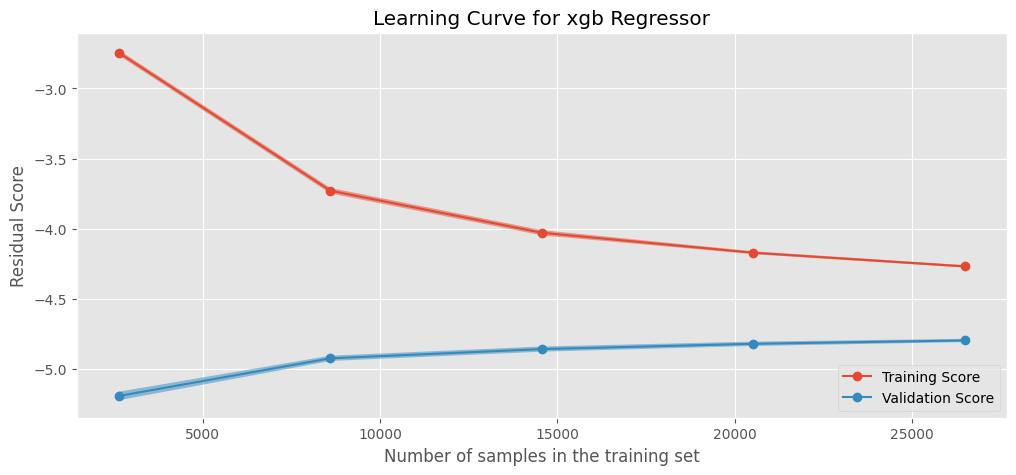

In [70]:
from sklearn.model_selection import LearningCurveDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# mengambil data yang sudah di preprocessing
X_train_encoded = final_model_xgb.named_steps['preprocessing'].transform(X_train)
column_names = final_model_xgb.named_steps['preprocessing'].get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded, columns=column_names)

# Mengambil model xgb yang sudah dilatih dari pipeline untuk SHAP
xgb_model = final_model_xgb.named_steps['model']

# Membuat plot learning curve
fig, ax = plt.subplots(figsize=(12, 5))

# Menentukan parameter untuk LearningCurveDisplay
common_params = {
    "X": X_train_df,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1, 5),
    "cv": 5,
    "scoring": "neg_root_mean_squared_error",  # Menggunakan RMSE bawaan Scikit-Learn
    "n_jobs": 4,
    "line_kw": {'marker': 'o'},
}

# Membuat learning curve display
LearningCurveDisplay.from_estimator(xgb_model, **common_params, ax=ax)

# Mengatur judul dan legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['Training Score', 'Validation Score'], loc='lower right')
ax.set_title('Learning Curve for xgb Regressor')
ax.set_ylabel('Residual Score')

# Menampilkan plot
plt.show()

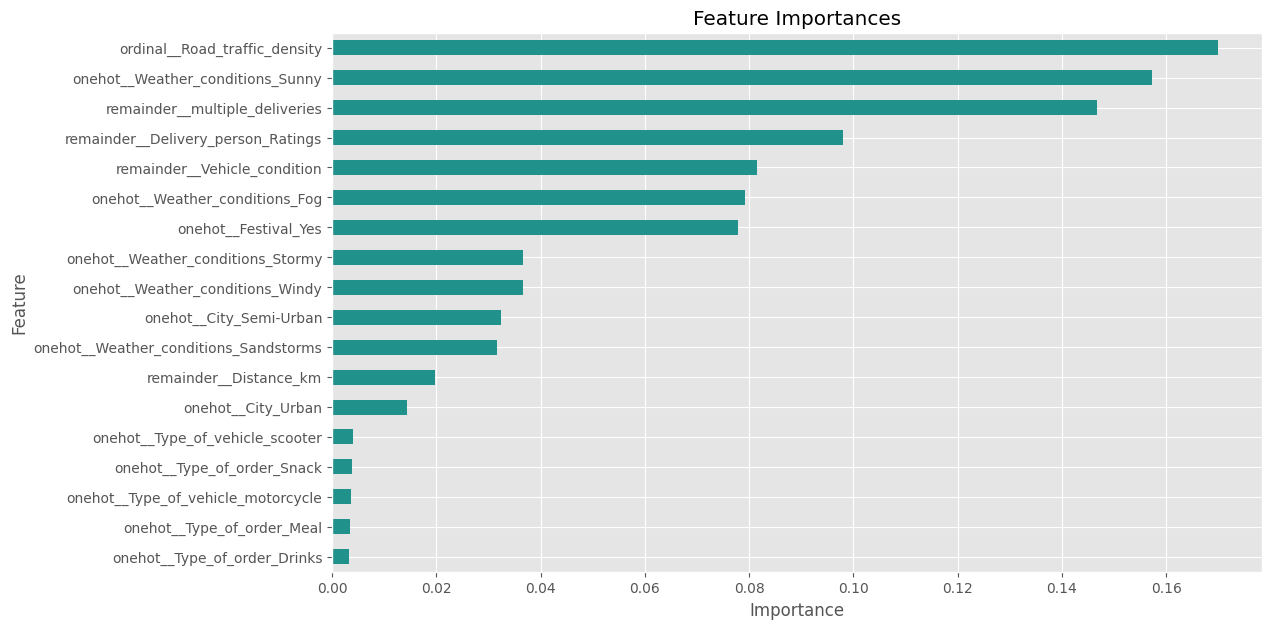

In [71]:
feature_names = ct.get_feature_names_out()

# Mengambil feature importances dari model LGBM dalam pipeline
# Jika `best_model_lxgb_rmse['model']` adalah objek XGBRegressor dalam pipeline, gunakan:
coef1 = pd.Series(final_model_xgb.named_steps['model'].feature_importances_, index=feature_names).sort_values(ascending=True)

# Plot feature importances
plt.figure(figsize=(12, 7))
coef1.plot(kind='barh', title='Feature Importances',color='#21918c')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

* The **most important factors** influencing the model are `Road_traffic_density` (traffic congestion), followed by `Weather_conditions_Sunny` (sunny weather) and `multiple_deliveries` (number of deliveries at once). Road and weather conditions have a significant impact on the model’s predictions — for example, delivery time.
* **Delivery person rating and vehicle condition** (`Delivery_person_Ratings` and `Vehicle_condition`) also have a notable influence.
* **Other weather factors** such as fog, stormy, windy, or sandstorms show moderate to low influence.
* **Type of vehicle or type of order** (`Type_of_vehicle` or `Type_of_order`) have very little impact, almost negligible in affecting predictions.
* **Distance and city type** (`Distance_km`, `City_Semi-Urban`, and `City_Urban`) have a moderate to low effect.

**Conclusion:**
The model is strongly influenced by key environmental and operational conditions (traffic, weather, and number of deliveries), while attributes such as vehicle type or order type are mostly irrelevant.


**Residual Plot**

In [72]:
from matplotlib.ticker import MaxNLocator

def plot_residual_new(name_y_test, name_y_pred, title):
    residuals = name_y_test - name_y_pred

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    # Plot residuals
    sns.scatterplot(x=name_y_pred, y=residuals, alpha=0.3, color='#008080', ax=ax[0])
    ax[0].hlines(y=0, xmin=min(name_y_pred), xmax=max(name_y_pred), colors='r', linestyles='dashed')
    ax[0].set_title(f'Residual Plot of {title}')
    ax[0].set_xlabel('Predicted Values (minutes)')
    ax[0].set_ylabel('Residuals (minutes)')
    ax[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    ax[0].yaxis.set_major_locator(MaxNLocator(integer=True))

    # Plot Actual vs Predicted
    sns.scatterplot(x=name_y_test, y=name_y_pred, color='#008080', ax=ax[1], alpha=0.3)
    ax[1].set_title(f'Actual vs Predicted of {title}')
    ax[1].set_xlabel('Actual Values (minutes)')
    ax[1].set_ylabel('Predicted Values (minutes)')
    ax[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    ax[1].yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()


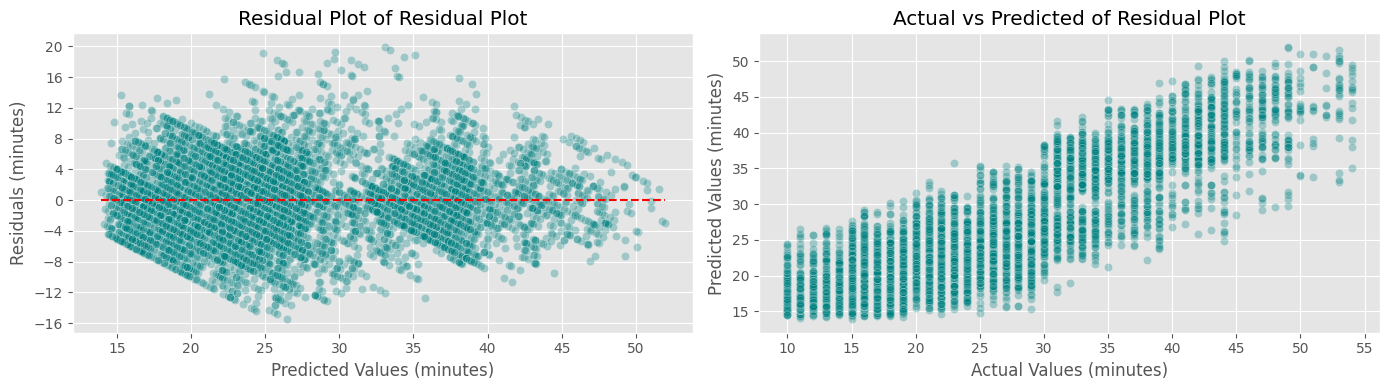

In [73]:
plot_residual_new(y_test,y_pred_final_model_xgb,"Residual Plot")




| Analysis Aspect                                           | Observation                                                                                                                                              | Deep Interpretation                                                                                                               | Model Implications                                                                                                                                                           |
| --------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Residual Distribution vs Predicted Values (Left Plot)** | Residual points are scattered above and below the zero line, but show a widening pattern in some areas (especially around predictions of 20–40 minutes). | The non-random pattern suggests possible **heteroskedasticity** — the error variance is not constant across the prediction range. | The model may be **less stable in certain prediction ranges**, e.g., for mid-range predicted values. Consider **target transformation or parameter tuning** to address this. |
| **Zero Line in Residual Plot**                            | Most residuals cluster around the zero line, with a few extreme deviations.                                                                              | Indicates that the model is **not heavily biased overall** (predictions are not systematically over- or under-estimated).         | The model shows **reasonable calibration**, though minor adjustments may improve error symmetry.                                                                             |
| **Residual Outliers**                                     | A few points have residuals far from zero (above +15 or below -12).                                                                                      | Suggests **some observations are difficult to predict** — possibly outliers or data with unique patterns.                         | Conduct **error analysis** on these extreme cases to make the model more robust.                                                                                             |
| **Residual Point Density**                                | Residual points are dense in some areas and sparse in others.                                                                                            | This indicates potential **nonlinearity** in the relationship between features and the target.                                    | Model performance could be improved by **adding nonlinear features** or **feature interactions**.                                                                            |
| **Actual vs Predicted Plot (Right Plot)**                 | Points generally follow the diagonal line well, though there is spread at higher values.                                                                 | Predictions tend to follow actual values, but **accuracy decreases for higher target values**.                                    | The model tends to **underestimate high actual values** — predictions fail to fully capture extreme variability.                                                             |
| **Consistency Across Both Plots**                         | Patterns in the residual plot align with the spread in the actual vs predicted plot.                                                                     | Indicates the model **does not fully generalize** across the entire target range.                                                 | Further **tuning is needed** (e.g., tree depth, learning rate, or adjusting the loss function).                                                                              |
| **Overall Conclusion**                                    | Patterns are generally good, residuals are nearly randomly distributed, but slight deviations exist in certain areas.                                    | The model performs well but is not optimal for extreme values and heterogeneous variability.                                      | **Next steps:** re-evaluate target distribution, perform XGBoost tuning, or consider log transformation of the target.                                                       |




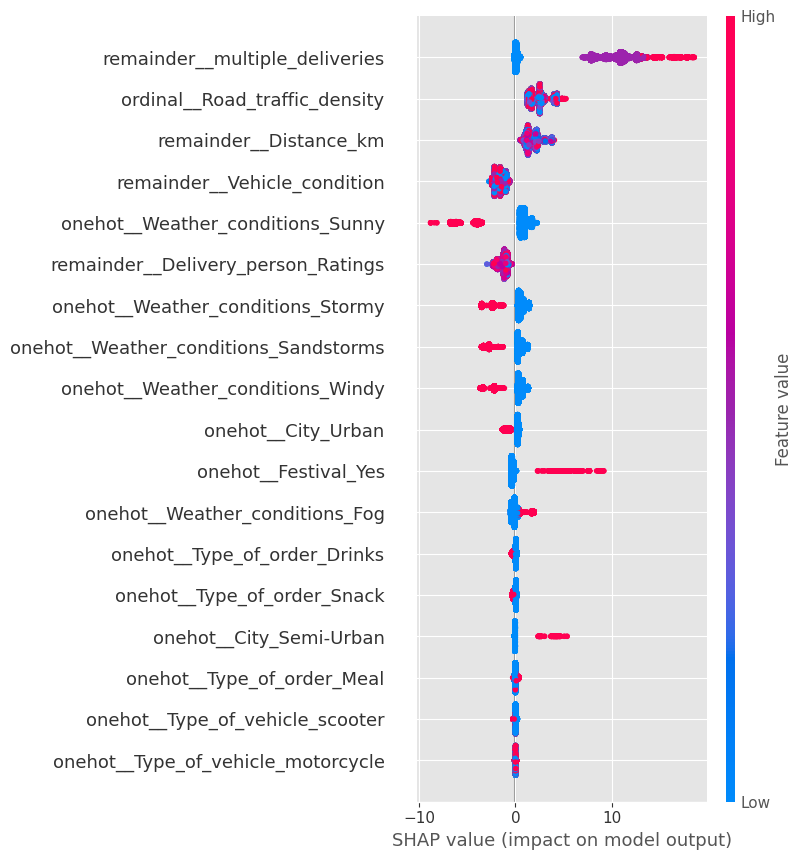

In [74]:
import shap

# Extract fitur yang telah diproses setelah encoding dari pipeline
X_train_encoded = final_model_xgb.named_steps['preprocessing'].transform(X_train)
column_names = final_model_xgb.named_steps['preprocessing'].get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded, columns=column_names)

# Mengambil model xgb yang sudah dilatih dari pipeline untuk SHAP
xgb_model = final_model_xgb.named_steps['model']

# Menggunakan TreeExplainer untuk SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_df)

# Membuat plot summary SHAP
plt.figure(figsize=(26, 14))
shap.summary_plot(shap_values, X_train_df, feature_names=column_names)
plt.show()



**Key Interpretation**

* **Most influential features** are `multiple_deliveries`, `Road_traffic_density`, `Distance_km`, `Vehicle_condition`, and `Weather_conditions_Sunny`.
* There are feature combinations that *increase* predicted delivery time (positive SHAP) and those that *decrease* it (negative SHAP).
* Plot colors: **red/magenta = high feature value**, **blue = low feature value**. Right position = pushes prediction higher (longer delivery time); left position = reduces prediction (shorter delivery time).

**Feature Interpretation**

1. **multiple_deliveries — (very strong, positive)**

   * Observation: red points (high values = many deliveries at once) are distributed far **to the right** → high values *increase* `Time_taken` predictions.
   * Practical meaning: when a courier carries multiple orders simultaneously, the model predicts significantly longer delivery times (largest effect among features).
   * Recommendation: prioritize route optimization / batching; consider this feature key for operational interventions.

2. **ordinal__Road_traffic_density — (strong, positive)**

   * Observation: high traffic values (magenta) are on the right → **high traffic density increases delivery time**.
   * Practical meaning: traffic is a major driver of delays.
   * Recommendation: add features for time of day, day of week, or real-time traffic sources; use for dynamic ETAs.

3. **remainder__Distance_km — (medium-strong, positive)**

   * Observation: longer distances push SHAP to the right → **longer distance → longer time**.
   * Practical meaning: logical — distance naturally affects duration.
   * Recommendation: use actual road distance (not straight line) and consider interactions like distance × traffic.

4. **remainder__Vehicle_condition — (medium, negative for good values)**

   * Observation: red points (high values) are **on the left** → higher vehicle condition **reduces predicted time**.
   * Practical meaning: better vehicle condition speeds up delivery.
   * Recommendation: include vehicle service/age details; use for priority task assignments.

5. **onehot__Weather_conditions_Sunny — (negative)**

   * Observation: high value (sunny = 1) appears on the left → **good weather tends to reduce time**.
   * Practical meaning: favorable weather accelerates delivery; adverse weather (storm, sandstorm) increases time.
   * Recommendation: add granular weather features (rain intensity, visibility) for more accurate estimates.

6. **remainder__Delivery_person_Ratings — (negative)**

   * Observation: high ratings (magenta) lie on the left → **higher-rated couriers tend to complete deliveries faster**.
   * Practical meaning: ratings can serve as a proxy for skill/speed.
   * Recommendation: use ratings for scheduling time-sensitive tasks.

7. **onehot__Festival_Yes — (medium positive)**

   * Observation: when festival = 1 (magenta), some points are on the right → events/holidays tend to **increase delivery time**.
   * Practical meaning: holidays may cause delays due to higher order volume and traffic.

8. **Other features (order type, city, fog, stormy, windy)**

   * Generally smaller effects, but some adverse weather or specific city types still contribute to longer times (though minor compared to top-3 features).

**Key Interactions & Nuances**

* **Potential strong interactions:** `multiple_deliveries × Distance` (many packages far away → large non-linear effect), `traffic × time_of_day`, `festival × traffic`. SHAP shows `multiple_deliveries` has high impact even when distance/traffic is moderate → batching alone has significant effect.
* **Causality is not absolute:** SHAP shows model contribution — not perfect cause-effect. For example, high rating correlates with faster time, but could be due to couriers being assigned shorter routes.

**Implications for Modeling & Operations (Actionable)**

1. **Feature engineering:** create interaction features (distance × multiple_deliveries, traffic × hour), use actual route distance, and add more granular weather features.
2. **Modeling:** consider non-linear/tree-based models to capture interactions; SHAP already indicates non-linear effects.
3. **Operations:** limit deliveries per trip during critical delivery time predictions; assign high-rated couriers to time-sensitive orders; adapt routing during peak hours/festivals.
4. **Monitoring:** use local SHAP explanations for per-case ETA explanation to customers or for evaluating delay cases.




In [75]:
shap.initjs()

In [76]:
def shap_plot(j, model, S):
    explainerModel = shap.TreeExplainer(model)
    shap_value_model = explainerModel.shap_values(S)
    p = shap.force_plot(
        explainerModel.expected_value,
        shap_value_model[j],                # nilai shap pada value index
        S.iloc[[j]])                        # data features pada index ke j
    return p

In [77]:
# Ekstrak langkah preprocessing dari pipeline
preprocessing_ct = final_model_xgb.named_steps['preprocessing']

# Terapkan transformasi langsung ke X_test
X_test_transformed = preprocessing_ct.transform(X_test)

# Dapatkan nama kolom dari ColumnTransformer
column_names = preprocessing_ct.get_feature_names_out()

# Buat DataFrame dengan kolom yang telah ditransformasikan
X_test_df = pd.DataFrame(X_test_transformed, columns=column_names)


In [78]:
def predict_and_shap_plot(index, model, data):
    # Memprediksi hasil berdasarkan nilai y pada indeks tertentu
    if y_test.iloc[index] <= 25 :
        print(f'Time Taken Under 25 minutes')
    elif y_test.iloc[index] > 26 and y_test.iloc[index] <= 40:
        print(f'Time Taken Upper 26 and Under 40 minutes')
    elif y_test.iloc[index] >= 41 :
        print(f'Time Taken Minute Upper 50 minutes')

    # Memanggil fungsi shap_plot
    return shap_plot(index, model, data)

**observation index 81**

In [79]:
print(f'nilai aktual : {y_test.iloc[81]}')
predict_and_shap_plot(81, final_model_xgb['model'], X_test_df) 

nilai aktual : 33
Time Taken Upper 26 and Under 40 minutes



**Features that Increase Prediction**

| Feature                                | Value                | Effect | Interpretation                                                                                   |
| -------------------------------------- | -------------------- | ------ | ------------------------------------------------------------------------------------------------ |
| `onehot__Weather_conditions_Sunny = 0` | Not sunny            | ⬆️     | Because the weather is not sunny (possibly cloudy/rainy), the predicted delivery time is longer. |
| `remainder__Distance_km = 19.34`       | Distance 19 km       | ⬆️     | Longer distance logically increases travel time.                                                 |
| `ordinal__Road_traffic_density = 2`    | Medium traffic       | ⬆️     | Traffic density adds to travel time.                                                             |
| `remainder__multiple_deliveries = 1`   | More than 1 delivery | ⬆️     | Multiple deliveries increase total duration.                                                     |

**Features that Decrease Prediction**

| Feature                                     | Value                  | Effect | Interpretation                                                                                                                     |
| ------------------------------------------- | ---------------------- | ------ | ---------------------------------------------------------------------------------------------------------------------------------- |
| `onehot__Weather_conditions_Sandstorms = 1` | Sandstorm weather      | ⬇️     | This is unusual, possibly an outlier; limited data may have caused the model to misinterpret sandstorm effects as faster delivery. |
| `remainder__Vehicle_condition = 1`          | Good vehicle condition | ⬇️     | A vehicle in good condition reduces delivery time.                                                                                 |


**Model Performance On MAPE Segmentation**

In [80]:
df_versus = pd.DataFrame({
    'Actual Time Taken minutes' :y_test.values,
    'Predicted Time Taken minutes' : y_pred_final_model_xgb.tolist()
})

df_versus['Time Category'] = pd.qcut(df_versus['Predicted Time Taken minutes'], q=3, labels=["low", "medium", "high"])

df_low_time = df_versus[df_versus['Time Category'] == 'low'].reset_index(drop=True)
df_medium_time = df_versus[df_versus['Time Category'] == 'medium'].reset_index(drop=True)
df_high_time = df_versus[df_versus['Time Category'] == 'high'].reset_index(drop=True)



df_low_time['abs error'] = np.abs(df_low_time['Actual Time Taken minutes'] - df_low_time['Predicted Time Taken minutes'])
df_low_time['abs persen error'] = (df_low_time['abs error'] / df_low_time['Actual Time Taken minutes'] * 100)

df_medium_time['abs error'] = np.abs(df_medium_time['Actual Time Taken minutes'] - df_medium_time['Predicted Time Taken minutes'])
df_medium_time['abs persen error'] = (df_medium_time['abs error'] / df_medium_time['Actual Time Taken minutes'] * 100)

df_high_time['abs error'] = np.abs(df_high_time['Actual Time Taken minutes'] - df_high_time['Predicted Time Taken minutes'])
df_high_time['abs persen error'] = (df_high_time['abs error'] / df_high_time['Actual Time Taken minutes'] * 100)


mape_low_time = df_low_time["abs persen error"].mean()
mape_medium_time = df_medium_time["abs persen error"].mean()
mape_high_time = df_high_time["abs persen error"].mean()

# Membuat DataFrame dari hasil perhitungan MAPE
data = {
    "Segmen Time": ["Low Time", "Medium Time", "High Time"],
    "MAPE": [mape_low_time, mape_medium_time, mape_high_time]
}

df_mape = pd.DataFrame(data)

df_mape

,Segmen Time,MAPE
0,Low Time,21.700334
1,Medium Time,17.586822
2,High Time,11.120523


In [81]:
display(
    f'Low Segmentation: ',
    df_versus[df_versus['Time Category'] == 'low']['Predicted Time Taken minutes'].describe().to_frame().loc[['min','max']].T,
    f'Medium Segmentation: ',
    df_versus[df_versus['Time Category'] == 'medium']['Predicted Time Taken minutes'].describe().to_frame().loc[['min','max']].T,
    f'High Segementation: ',
    df_versus[df_versus['Time Category'] == 'high']['Predicted Time Taken minutes'].describe().to_frame().loc[['min','max']].T
)



'Low Segmentation: '

,min,max
Predicted Time Taken minutes,13.917354,22.338955


'Medium Segmentation: '

,min,max
Predicted Time Taken minutes,22.340414,27.370296


'High Segementation: '

,min,max
Predicted Time Taken minutes,27.371468,51.982254


In [82]:
def horizontal_barplot_with_annotations(df, x_col, y_col, hue_col=None, palette='viridis', title='Model Performance', xlabel='MAPE', ylabel='Segmentation'):

    # Membuat horizontal barplot
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=df, y=y_col, x=x_col, hue=hue_col, palette=palette, ax=ax)
    
    # Menambahkan anotasi pada setiap bar
    for bar in ax.patches:
        x, y = bar.get_xy()
        ax.text(
            x + bar.get_width(), y + bar.get_height()/2, f'{bar.get_width():.2f} %',
            va='center', ha='right', color='white'
        )

    # Menambahkan judul dan label sumbu
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    # Menampilkan plot
    plt.show()

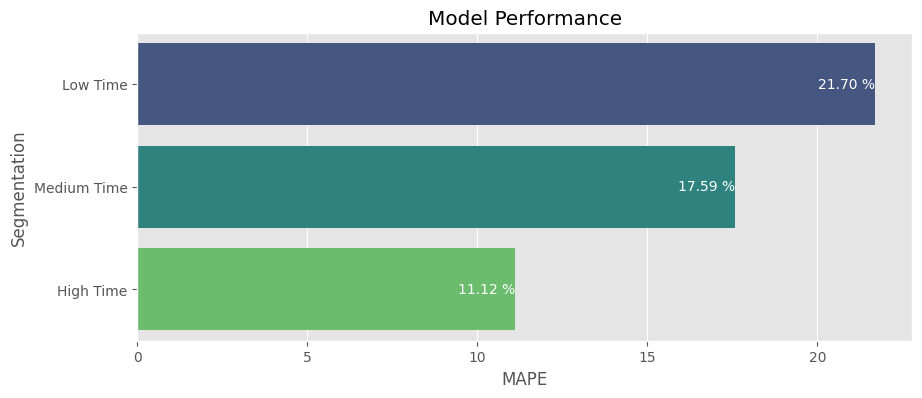

In [83]:
horizontal_barplot_with_annotations(df_mape,'MAPE','Segmen Time')



| **Time Segment** | **Predicted Time Range (minutes)** | **MAPE (%)** | **Accuracy Interpretation**       | **Analysis of Possible Causes & Patterns**                                                                                                                                                                                    | **Implications for the Model**                                                                                                                                                  |
| ---------------- | ---------------------------------- | ------------ | --------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Low Time**     | 13.9 – 22.3                        | **21.70%**   | **Low (weak accuracy)**           | For very short delivery times, the model struggles to predict small variations (e.g., short delays or route differences). High noise in this segment may come from random factors like restaurant wait time or local weather. | The model is less sensitive to micro-level factors affecting short durations. Improvement requires additional features such as *pickup delay* or *restaurant preparation time*. |
| **Medium Time**  | 22.3 – 27.3                        | **17.59%**   | **Medium (fairly good accuracy)** | The model becomes more stable as delivery time patterns in this segment are more consistent and representative of training data. Error decreases due to relatively lower variability.                                         | This segment reflects the model’s optimal performance area — current parameters and features work reasonably well.                                                              |
| **High Time**    | 27.4 – 52.0                        | **11.12%**   | **High (very good accuracy)**     | The model predicts long delivery times very well. Dominant factors (long distance, high traffic, multiple deliveries) are easier to capture for XGBoost, which is sensitive to nonlinear patterns.                            | The model effectively captures complex relationships between distance, traffic density, and weather. This segment is the most stable with the best generalization.              |

**Conclusion**

| Aspect                  | Summary                                                                            |
| ----------------------- | ---------------------------------------------------------------------------------- |
| **Best performance**    | **High Time** segment — because the model clearly recognizes macro-level patterns. |
| **Weakest performance** | **Low Time** segment — due to high variability and potential local noise.          |




### **Conclusion & Recommendation**

#### **1. Project Overview**

This study focuses on developing a **machine learning regression model** to **predict delivery time (Time Taken)** for app-based food delivery services.

Delivery speed is a key factor in **customer satisfaction** and a **competitive advantage** for logistics and food delivery companies. Accurate time estimation helps the company to:

* Optimize **courier allocation and delivery routes**,
* Increase **transparency for customers**, and
* Reduce **operational costs due to incorrect estimations**.

A **machine learning approach** was chosen because it can **capture complex, non-linear patterns** in variables affecting delivery time, such as traffic conditions, weather, courier characteristics, and geographic distance. Traditional approaches (e.g., average calculations or simple linear regression) often fail to accurately represent interactions among these variables.

---

#### **2. Dataset Summary & Exploratory Analysis**

The dataset contains **45,584 observations** covering courier demographics, operational conditions, and geographic factors. Descriptive statistics show delivery times ranging from **10 to 54 minutes**, with an average of **26.29 minutes**.

Key findings from **Exploratory Data Analysis (EDA)**:

| Key Factor               | Category / Value                  | Impact on Delivery Time | Interpretation                                                              |
| ------------------------ | --------------------------------- | ----------------------- | --------------------------------------------------------------------------- |
| **City**                 | Semi-Urban (49 min)               | Very High               | Inefficient infrastructure and routes result in the longest delivery times. |
| **Festival**             | Yes (45 min)                      | High                    | Significant demand surge and congestion.                                    |
| **Road Traffic Density** | Peak (31 min)                     | High                    | Most influential operational factor daily.                                  |
| **Weather Conditions**   | Cloudy/Fog (29 min)               | Medium                  | Adverse weather slows down deliveries.                                      |
| **Type of Vehicle**      | Scooter/Electric Scooter (24 min) | Low                     | More efficient in dense traffic.                                            |
| **Type of Order**        | All categories similar (26 min)   | Neutral                 | Not significant for delivery time.                                          |

**Key insight:** Semi-Urban areas and Festival periods are the most critical factors increasing delivery time, while sunny weather and low traffic contribute to efficiency.

---

#### **3. Model Performance Summary**

Several models were tested, including **Linear Regression**, **Random Forest**, **CatBoost**, and **XGBRegressor**.

| Model                   | RMSE      | MAE       | MAPE        | Ranking | Notes                                                                |
| ----------------------- | --------- | --------- | ----------- | ------- | -------------------------------------------------------------------- |
| **XGBRegressor (Best)** | **4.775** | **3.765** | **16.803%** | 🥇 1    | Highest accuracy and stable across train, validation, and test sets. |
| CatBoost                | 4.776     | 3.772     | 16.831%     | 🥈 2    | Performance nearly equal to XGB.                                     |
| Random Forest           | 4.802     | 3.788     | **16.800%** | 🥉 3    | Low MAPE but higher error variance.                                  |

The **XGBRegressor** was selected as the final model because it provides the best balance between **accuracy (RMSE, MAE)** and **stability (MAPE)**.
After tuning (`subsample=0.6, n_estimators=500, max_depth=10, learning_rate=0.01`), performance consistently improved across all metrics.

---

#### **4. Feature Importance & Interpretation**

The most influential features for predicting delivery time are:

| Rank | Feature                     | Impact on Time | Interpretation                                                   |
| ---- | --------------------------- | -------------- | ---------------------------------------------------------------- |
| 1    | **Road Traffic Density**    | Positive       | Heavy traffic significantly increases delivery time.             |
| 2    | **Weather Conditions**      | Positive       | Adverse weather prolongs delivery time.                          |
| 3    | **Multiple Deliveries**     | Positive       | Multiple deliveries in a single trip cause delays.               |
| 4    | **Delivery Person Ratings** | Negative       | High-rated couriers tend to deliver faster and more efficiently. |

---

#### **5. Business Conclusion**

The **XGBRegressor** model with **MAPE 16.8%** provides highly accurate delivery time predictions.
Segment analysis shows the model performs best in the **High-Time Segment** (MAPE = 11.12%), demonstrating strong predictive capability for long-duration deliveries.

| Time Segment  | MAPE       | Interpretation                                   |
| ------------- | ---------- | ------------------------------------------------ |
| Low-Time      | 21.70%     | High variability for short deliveries.           |
| Medium-Time   | 17.58%     | Performance fairly stable.                       |
| **High-Time** | **11.12%** | Highly accurate predictions for long deliveries. |

Therefore, this model is **suitable for initial implementation** in a *delivery ETA prediction system*.
Companies can integrate it into operational dashboards to provide more realistic delivery time estimates for customers and logistics managers.

---

#### **6. Why Machine Learning?**

Machine learning provides significant advantages over traditional methods like historical averages or simple linear regression:

| Aspect              | Traditional Method                               | Machine Learning                                                     |
| ------------------- | ------------------------------------------------ | -------------------------------------------------------------------- |
| Data Complexity     | Only handles linear relationships                | Can learn non-linear feature interactions (e.g., traffic × weather). |
| Adaptability        | Difficult to adapt to changing conditions        | Can be updated regularly with new data.                              |
| Prediction Accuracy | General and non-specific predictions             | Can achieve low error (<17%) with tuning and spatial features.       |
| Business Impact     | Estimates often inaccurate → customer complaints | Accurate predictions → improved satisfaction and route efficiency.   |

In other words, machine learning can **convert operational data into precise business decisions**, resulting in cost efficiency, higher courier productivity, and improved customer satisfaction.

---

#### **7. Recommendations**

**A. Business Strategies**

1. **Delivery Route Optimization**
   Use predicted delivery times to determine the fastest routes based on real-time traffic and weather conditions.

2. **Resource Adjustment During Festival Periods**
   Increase courier numbers or delivery time allocation in Semi-Urban areas during high-demand periods.

3. **Courier Incentive System**
   Provide incentives to high-rated couriers as they significantly influence delivery efficiency.

4. **Enhanced Customer Transparency**
   Integrate the model into the app to show customers more accurate delivery time estimates.

**B. Technical Strategies**

1. **Integration of Geodesic Spatial Data**
   Use actual distances (haversine/geodesic) instead of city-level representation.

2. **Model Deployment via API / Dashboard**
   Implement XGBRegressor in the backend to allow automatic access to predictions by the application.

3. **Continuous Model Development**
   Retrain the model periodically (e.g., monthly) to maintain accuracy with the latest data.

4. **Experiment with Dynamic Features**
   Add features like *real-time traffic density*, *rainfall intensity*, or *delivery clustering by zone* to further improve model performance.

---

#### **8. Closing Note**

With a **MAPE of 16.8%**, the model demonstrates strong and stable predictive capability.
The machine learning regression approach has proven superior to conventional methods, providing **actionable insights** for operational and strategic decision-making in modern logistics.



In [ ]:
# saving model

# import pickle 
# final_model_xgb.fit(X,y)

# pickle.dump(final_model_xgb, open('best_model_xgb_zomato.sav', 'wb'))